# SDV Models: Comprehensive Evaluation - AD Dataset

This notebook contains a comprehensive evaluation of four synthetic data generation models on the Alzheimer's Disease (AD) dataset:
1. **CopulaGAN** - GAN-based with copula modeling
2. **Gaussian Copula** - Statistical copula-based approach
3. **CTGAN** - Conditional Tabular GAN
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## 1. Data Loading and Setup


In [2]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 1. Load the data (walk up from notebook cwd → repo Datasets/)
_here = Path.cwd().resolve()
_roots = [_here, *_here.parents]
candidate_names = ["Alzhimers.xlsx", "Alzheimer.xlsx", "Alzheimer.csv", "clean_alzheimer.csv"]
candidate_paths = []
for root in _roots:
    for name in candidate_names:
        candidate_paths.append(root / "Datasets" / name)
        candidate_paths.append(root / name)
    candidate_paths.append(root / "Synthetic_Data_Audit" / "Datasets" / "Alzhimers.xlsx")

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    ds_dir = next((r / "Datasets" for r in _roots if (r / "Datasets").is_dir()), None)
    available = sorted(p.name for p in ds_dir.glob("*")) if ds_dir else []
    raise FileNotFoundError(
        "Alzheimer dataset file not found. Expected Datasets/Alzhimers.xlsx under the repo root. "
        f"Available dataset files: {available}"
    )
print(f"Loading: {data_path}")

ad_data = pd.read_excel(data_path)

# 2. Remove columns we don't need
# errors='ignore' means "don't crash if these columns are already gone"
ad_data = ad_data.drop(columns=['Subject ID', 'M/F', 'MRI ID', 'Hand'], errors='ignore')

# 3. Convert text to numbers (Encoding)
# We use .replace() which is easier to read than .map()
ad_data['Group'] = ad_data['Group'].replace({'Demented': 1, 'Nondemented': 0, 'Converted': 1})

# 4. Handle missing values (The easy way)
# Fill all missing numbers with the average (mean) automatically
ad_data = ad_data.fillna(ad_data.mean(numeric_only=True))

# If there are still missing values (in text columns), fill them with the most common value
for col in ad_data.columns:
    if ad_data[col].isnull().any():
        ad_data[col] = ad_data[col].fillna(ad_data[col].mode()[0])

# 5. Show the result
print("Data cleaned successfully!")
print(ad_data.head())

# 6. Detect Metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(ad_data)
print(f"Metadata detected. Columns found: {len(ad_data.columns)}")

Loading: /home/gopi.battineni/SYNTH_BENCHMARK/Datasets/Alzhimers.xlsx
Data cleaned successfully!
   Group  Visit  MR Delay  Age  EDUC       SES  MMSE  CDR         eTIV  \
0      0      1         0   87    14  2.000000  27.0  0.0  1986.550000   
1      0      2       457   88    14  2.000000  30.0  0.0  2004.479526   
2      1      1         0   75    12  2.460452  23.0  0.5  1678.290000   
3      1      2       560   76    12  2.460452  28.0  0.5  1737.620000   
4      1      3      1895   80    12  2.460452  22.0  0.5  1697.911134   

       nWBV       ASF  
0  0.696106  0.883440  
1  0.681062  0.875539  
2  0.736336  1.045710  
3  0.713402  1.010000  
4  0.701236  1.033623  
Metadata detected. Columns found: 11


# 2. Generating Synthetic data for Four SDV Models

In [3]:
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic
import pandas as pd

# Use the dataset you loaded in this notebook
real_data = ad_data.copy()

# Number of synthetic rows to generate per model
n_samples = 1000

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(real_data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=real_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data=real_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 857.99it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 340.31it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 607.36it/s]|
Column Shapes Score: 76.19%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 357.20it/s]|
Column Pair Trends Score: 59.39%

Overall Score (Average): 67.79%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 1928.42it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 594.09it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 645.77it/s]|
Column Shapes Score: 78.81%

(2/2) E

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.789691
1,TVAE,1.0,0.754273
2,CopulaGAN,1.0,0.679902
3,CTGAN,1.0,0.677912



Best model by quality score: GaussianCopula


,Group,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,1,1,0,76,12,3.030363,29.573527,0.0,1358.795417,0.735247,1.291664
1,0,3,53,75,19,2.099380,29.642557,0.0,1916.346806,0.712733,0.919015
2,1,1,0,64,22,2.041049,29.931825,0.0,1784.827336,0.752077,0.981103
3,0,2,27,84,11,3.782498,26.932574,0.7,1484.084148,0.694325,1.185540
4,1,1,0,73,17,2.265852,29.296849,0.0,1558.770376,0.727525,1.126724


# 1. Univariate Analysis
#### 1.1. Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 534.80it/s]|
Column Shapes Score: 76.19%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 354.76it/s]|
Column Pair Trends Score: 59.39%

Overall Score (Average): 67.79%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 623.83it/s]|
Column Shapes Score: 78.81%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 358.44it/s]|
Column Pair Trends Score: 57.17%

Overall Score (Average): 67.99%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 682.52it/s]|
Column Shapes Score: 82.15%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 360.27it/s]|
Column Pair Trends Score: 68.71%

Overall Score (Average): 75.43%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 654.73it/s]|
Column Shapes Score: 81.58%

(2/2) Evaluating Column Pair T

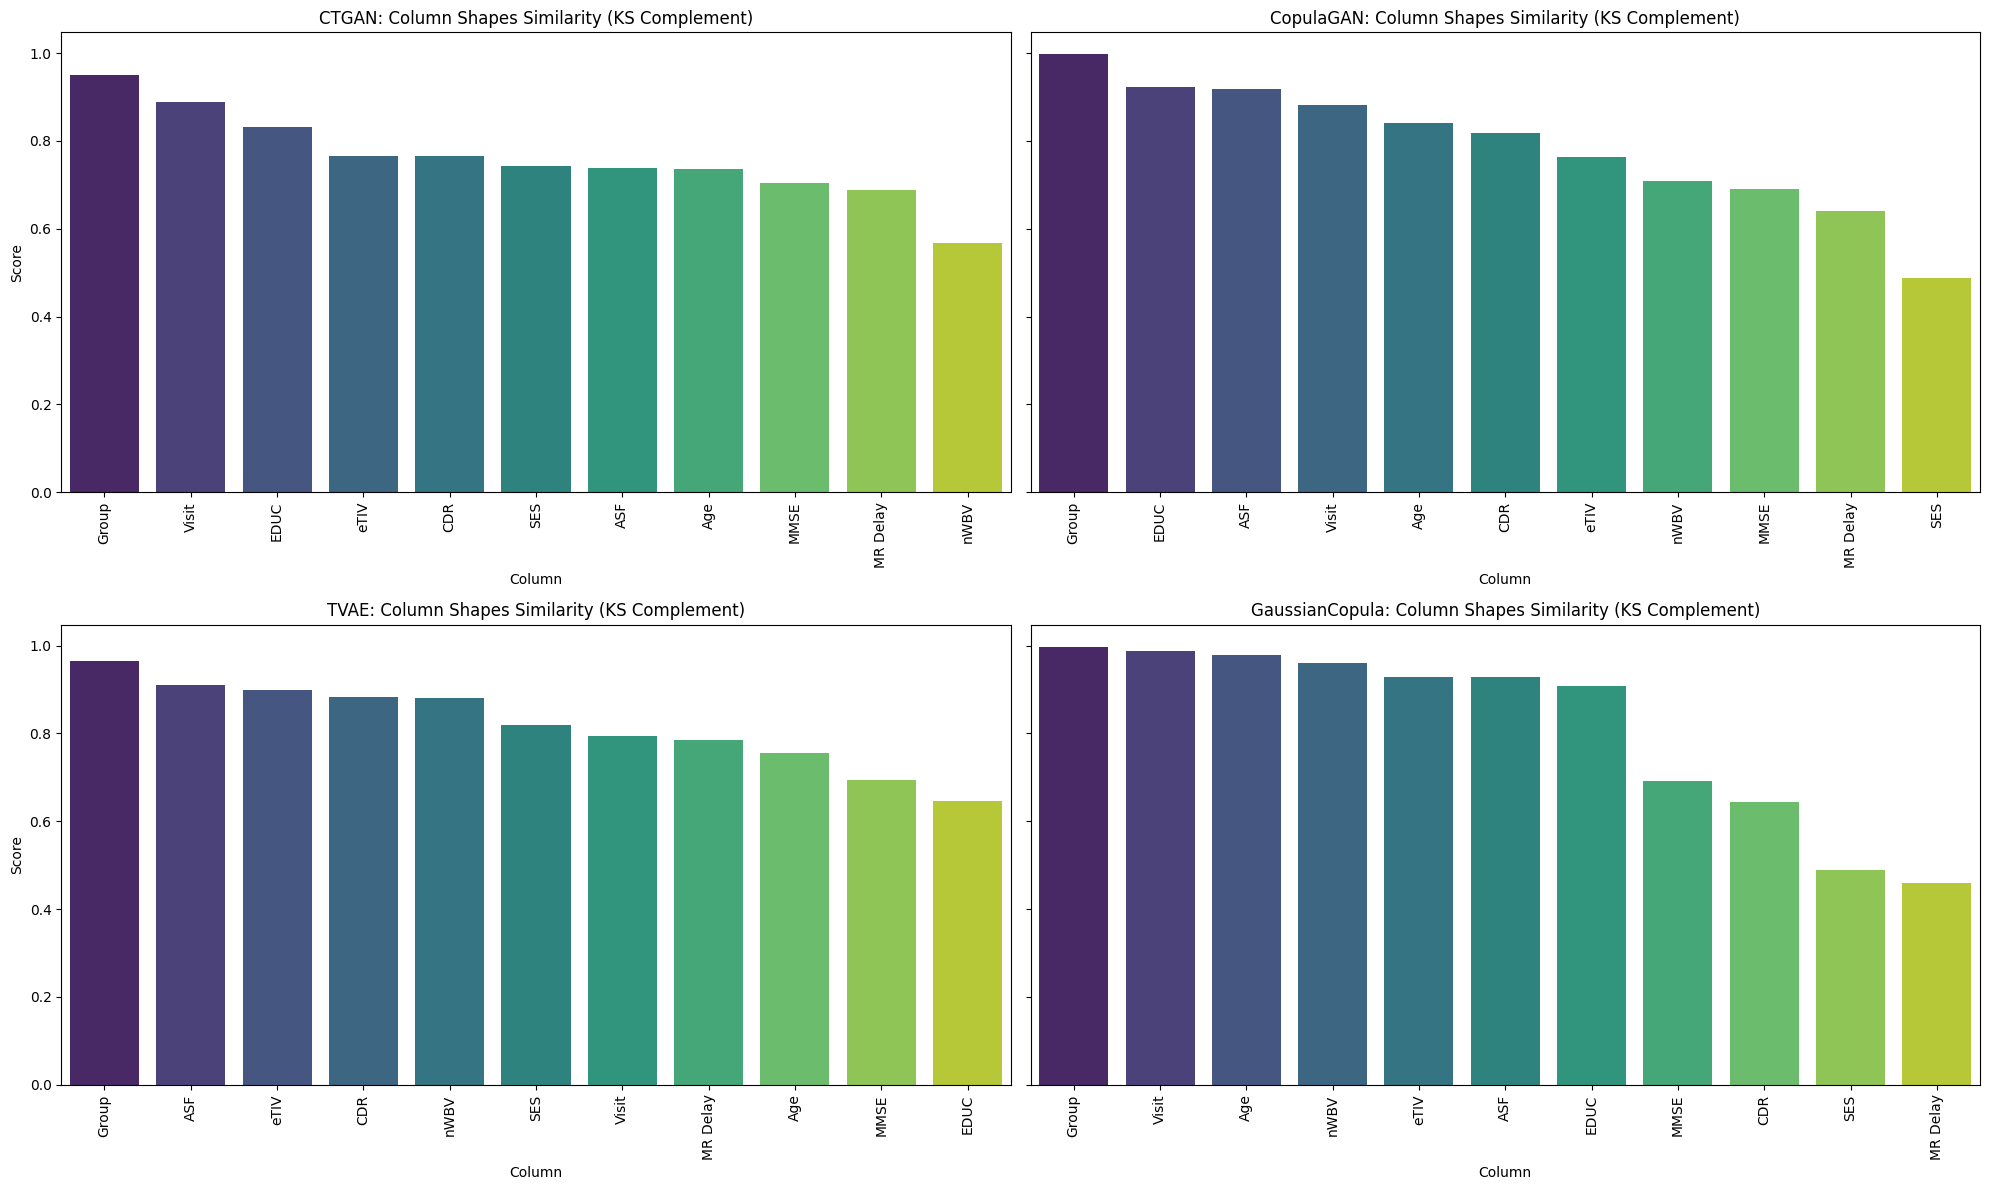

,Column,Metric,Score,Model
0,Group,TVComplement,0.950383,CTGAN
1,Visit,TVComplement,0.888796,CTGAN
2,EDUC,KSComplement,0.832340,CTGAN
3,eTIV,KSComplement,0.766643,CTGAN
4,CDR,KSComplement,0.765279,CTGAN
5,SES,KSComplement,0.742936,CTGAN
6,ASF,KSComplement,0.739121,CTGAN
7,Age,KSComplement,0.736182,CTGAN
8,MMSE,KSComplement,0.704402,CTGAN
9,MR Delay,KSComplement,0.687855,CTGAN


In [4]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
column_shape_details = {}

for model_name in model_order:
    qr = QualityReport()
    qr.generate(
        real_data=real_data,
        synthetic_data=synthetic_datasets[model_name],
        metadata=metadata.to_dict()
    )
    details = qr.get_details(property_name="Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

#### 1.2. Jensen–Shannon divergence

In [5]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()
    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)
    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]
        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)
        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

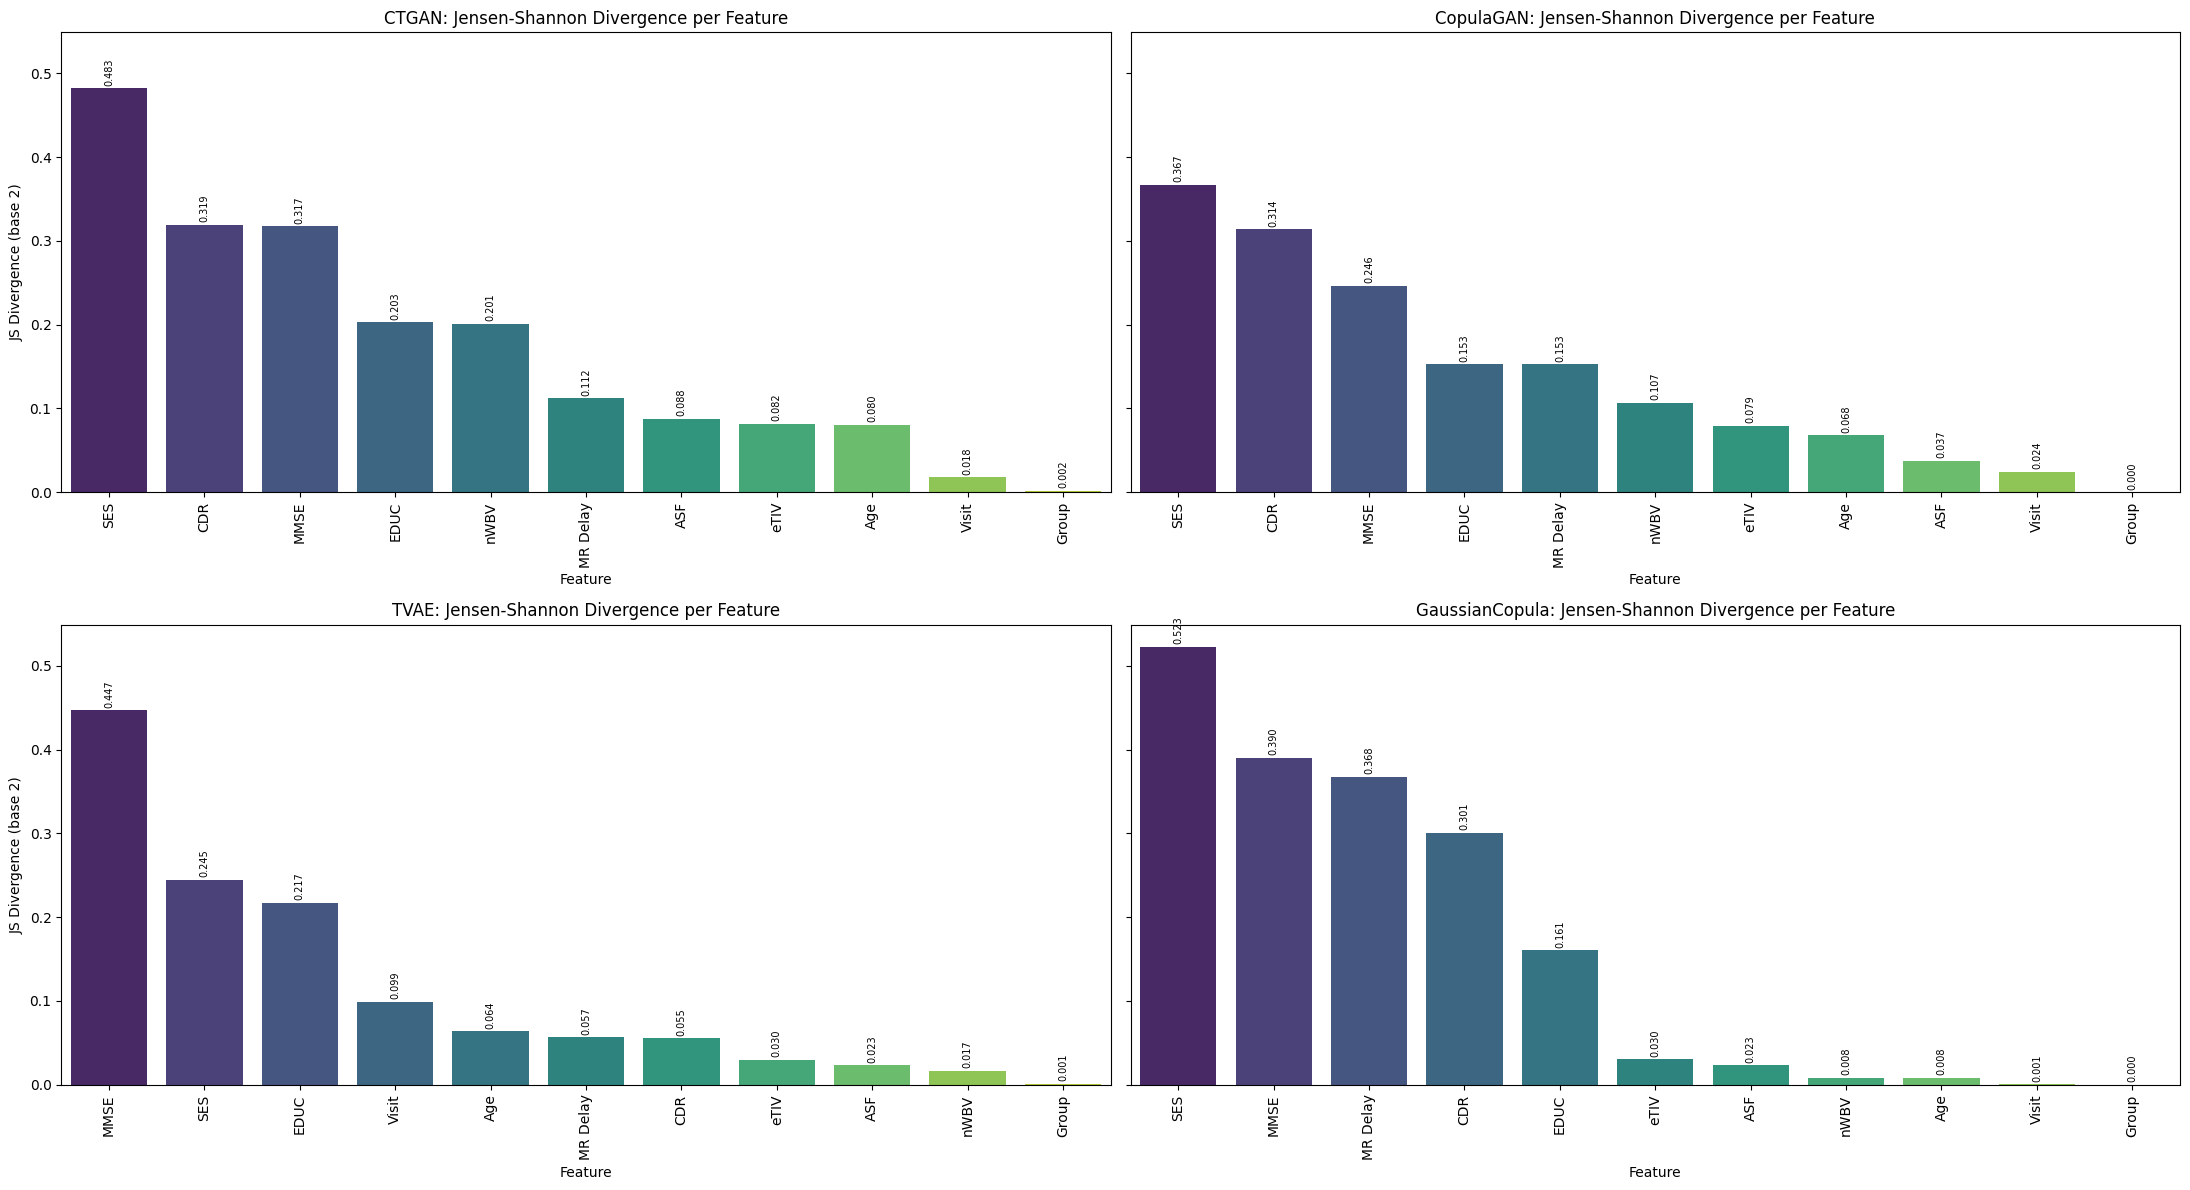

,Feature,JS_Divergence,Model
0,SES,0.482579,CTGAN
1,CDR,0.319306,CTGAN
2,MMSE,0.317483,CTGAN
3,EDUC,0.202714,CTGAN
4,nWBV,0.200891,CTGAN
5,MR Delay,0.112139,CTGAN
6,ASF,0.087548,CTGAN
7,eTIV,0.081962,CTGAN
8,Age,0.080390,CTGAN
9,Visit,0.017996,CTGAN


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

for model_name in model_order:
    js_df = compute_js_divergence(
        real_data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

#### 1.3 Wasserstein Distance

In [25]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

real_data = ad_data.copy()
numeric_cols = real_data.select_dtypes(include=[np.number]).columns
wasserstein_results = {}

for model_name, synth_df in synthetic_datasets.items():
    common_numeric_cols = [c for c in numeric_cols if c in synth_df.columns]
    scaler = StandardScaler().fit(real_data[common_numeric_cols])

    real_scaled = pd.DataFrame(
        scaler.transform(real_data[common_numeric_cols]),
        columns=common_numeric_cols
    )
    synth_scaled = pd.DataFrame(
        scaler.transform(synth_df[common_numeric_cols]),
        columns=common_numeric_cols
    )

    wasserstein_scores = []
    for col in common_numeric_cols:
        r = real_scaled[col].dropna().astype(float)
        s = synth_scaled[col].dropna().astype(float)

        try:
            w_dist = wasserstein_distance(r, s)
        except Exception:
            w_dist = np.nan

        wasserstein_scores.append({"Column": col, "Wasserstein": w_dist})

    results_df = pd.DataFrame(wasserstein_scores).sort_values("Wasserstein")
    wasserstein_results[model_name] = results_df

    print(f"\nWasserstein distances for {model_name}:")
    print(results_df)


Wasserstein distances for CTGAN:
      Column  Wasserstein
0      Group     0.099251
5        SES     0.266462
4       EDUC     0.320845
1      Visit     0.324393
6       MMSE     0.326646
7        CDR     0.358296
8       eTIV     0.427546
10       ASF     0.508538
3        Age     0.599261
2   MR Delay     0.743672
9       nWBV     1.213968

Wasserstein distances for CopulaGAN:
      Column  Wasserstein
0      Group     0.005234
10       ASF     0.123284
4       EDUC     0.203869
6       MMSE     0.213432
1      Visit     0.343924
3        Age     0.394893
7        CDR     0.452319
8       eTIV     0.453501
2   MR Delay     0.511856
9       nWBV     0.571035
5        SES     0.616862

Wasserstein distances for TVAE:
      Column  Wasserstein
0      Group     0.068779
8       eTIV     0.139847
5        SES     0.150509
10       ASF     0.168572
9       nWBV     0.209013
2   MR Delay     0.237218
7        CDR     0.272379
6       MMSE     0.316404
1      Visit     0.436236
3        Ag


CTGAN - Wasserstein Distance:
Group: 0.0496
Visit: 0.0747
MR Delay: 0.1788
Age: 0.1203
EDUC: 0.0542
SES: 0.0735
MMSE: 0.0461
CDR: 0.0670
eTIV: 0.0837
nWBV: 0.2340
ASF: 0.0985

CopulaGAN - Wasserstein Distance:
Group: 0.0026
Visit: 0.0792
MR Delay: 0.1231
Age: 0.0793
EDUC: 0.0344
SES: 0.1701
MMSE: 0.0301
CDR: 0.0846
eTIV: 0.0887
nWBV: 0.1101
ASF: 0.0239

TVAE - Wasserstein Distance:
Group: 0.0344
Visit: 0.1005
MR Delay: 0.0570
Age: 0.0923
EDUC: 0.0871
SES: 0.0415
MMSE: 0.0446
CDR: 0.0509
eTIV: 0.0274
nWBV: 0.0403
ASF: 0.0327

GaussianCopula - Wasserstein Distance:
Group: 0.0034
Visit: 0.0043
MR Delay: 0.2004
Age: 0.0068
EDUC: 0.0307
SES: 0.1231
MMSE: 0.0619
CDR: 0.0901
eTIV: 0.0176
nWBV: 0.0086
ASF: 0.0182

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,GaussianCopula,0.051368,0.018232,0.200376
1,TVAE,0.055345,0.044642,0.100509
2,CopulaGAN,0.075112,0.079298,0.170128
3,CTGAN,0.098230,0.074741,0.233979


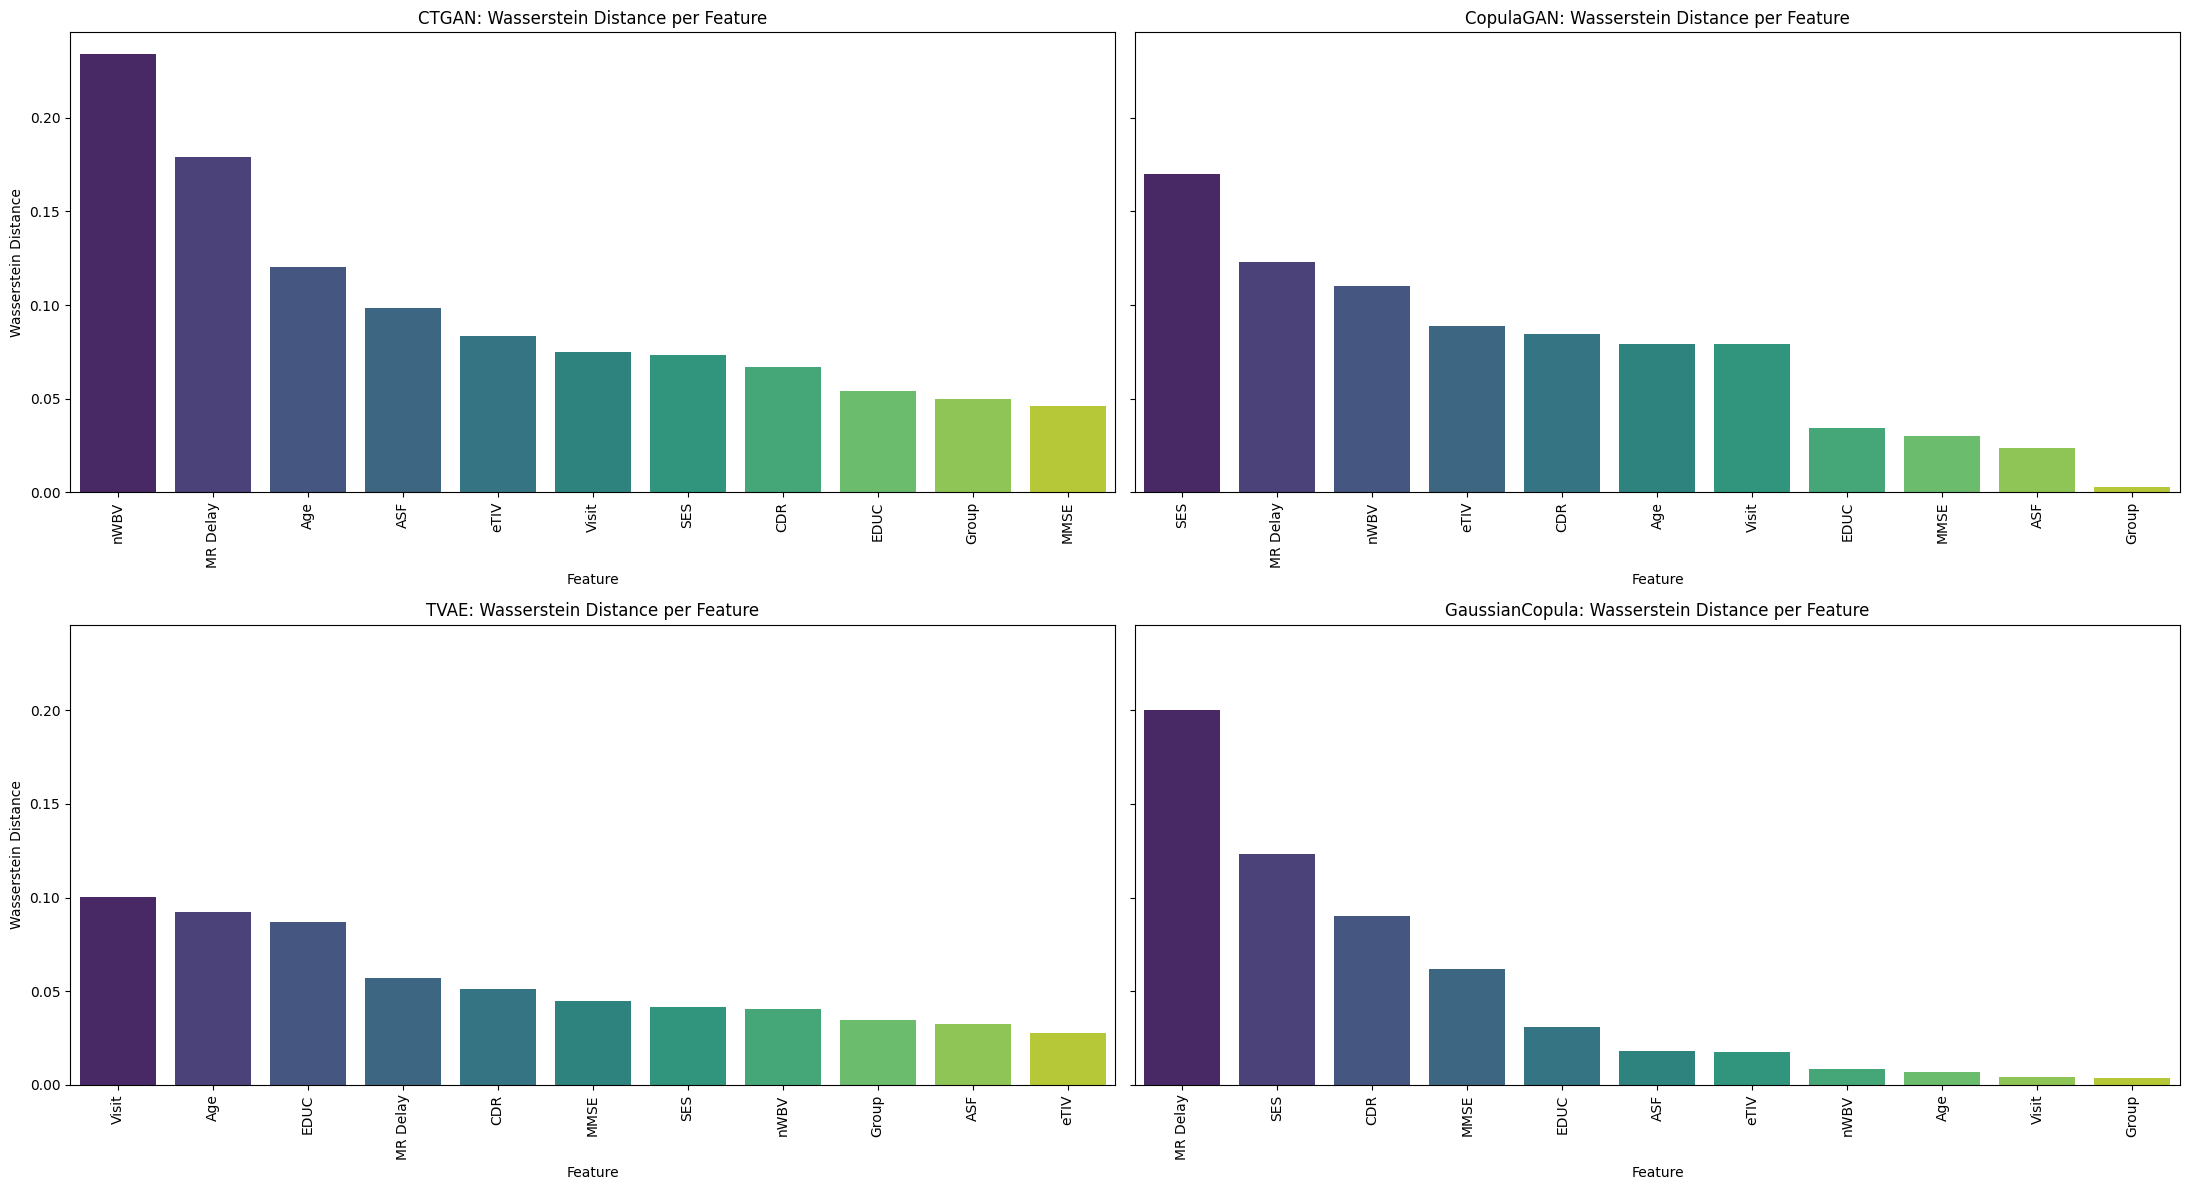

In [26]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

numeric_cols = real_data.select_dtypes(include="number").columns.tolist()
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_data[numeric_cols]),
    columns=numeric_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    common_cols = [c for c in numeric_cols if c in synth_df.columns]
    synth_df = synth_df[common_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=common_cols
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in common_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

#### 1.4 Gower Distance 

In [27]:
import numpy as np
import pandas as pd
import gower

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

X_real = real_data.drop(columns=[target_col], errors="ignore")
gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore")

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)

    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9877, Avg = 0.7802

Intra-set Similarity (Synthetic):
Max = 0.9701, Avg = 0.7369

Cross-set Similarity (Real vs Synthetic):
Max = 0.9621, Avg = 0.7426

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9877, Avg = 0.7802

Intra-set Similarity (Synthetic):
Max = 0.9827, Avg = 0.7393

Cross-set Similarity (Real vs Synthetic):
Max = 0.9722, Avg = 0.7535

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9877, Avg = 0.7802

Intra-set Similarity (Synthetic):
Max = 0.9899, Avg = 0.7582

Cross-set Similarity (Real vs Synthetic):
Max = 0.9958, Avg = 0.7889

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9877, Avg = 0.7802

Intra-set Similarity (Synthetic):
Max = 0.9916, Avg = 0.8080

Cross-set Similarity (Real vs Synthetic):
Max = 0.9867, Avg = 0.7915


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,0.987699,0.780247,0.970091,0.736880,0.962136,0.742585
1,CopulaGAN,0.987699,0.780247,0.982704,0.739260,0.972158,0.753542
2,TVAE,0.987699,0.780247,0.989940,0.758207,0.995789,0.788900
3,GaussianCopula,0.987699,0.780247,0.991580,0.808031,0.986670,0.791535


#### 1.5. t-SNE Visualization

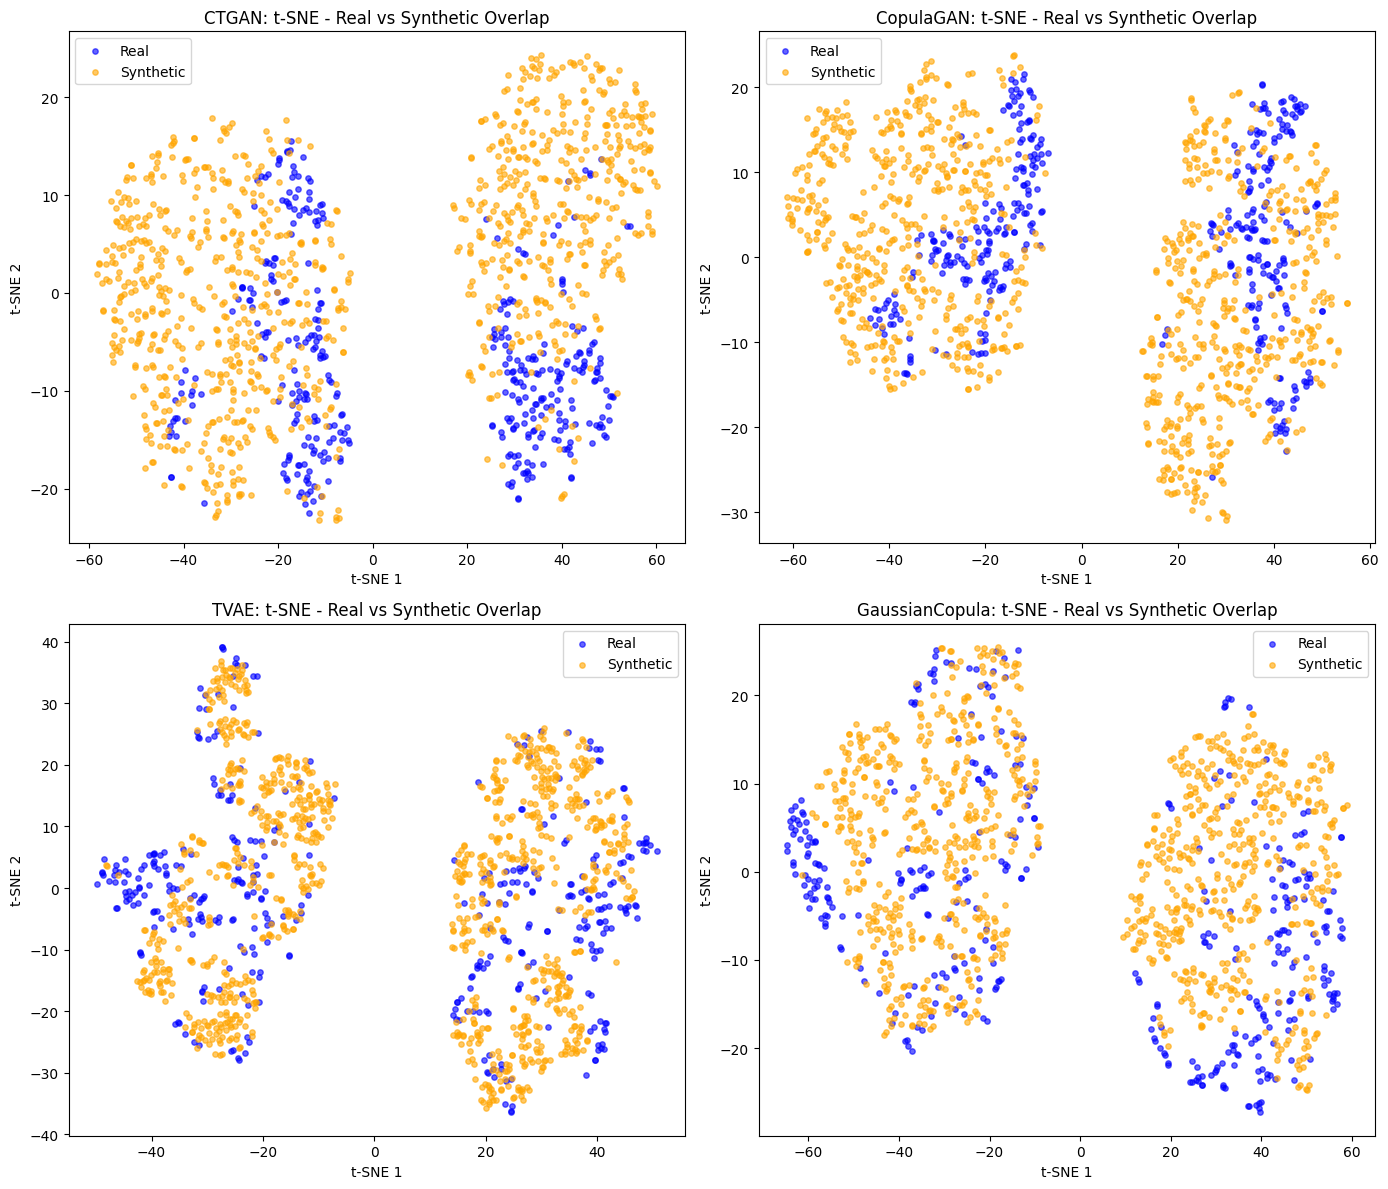

In [28]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

numeric_cols = real_data.select_dtypes(include="number").columns.tolist()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_data[numeric_cols]),
    columns=numeric_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name].copy()
    common_cols = [c for c in numeric_cols if c in synth_df.columns]
    synth_df = synth_df[common_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=common_cols
    )

    combined = np.vstack([real_scaled[common_cols].values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

#### 1.6 MMD (Maximum Mean Discrepancy)

In [29]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

real_features = real_data.drop(columns=[target_col], errors="ignore")
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.4f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.1083
CopulaGAN - MMD score: 0.0665
TVAE - MMD score: 0.0426
GaussianCopula - MMD score: 0.0531

MMD comparison (lower is better):


,Model,MMD_Score
0,TVAE,0.042622
1,GaussianCopula,0.053118
2,CopulaGAN,0.066517
3,CTGAN,0.108334


### 1.7 Cosine Similarity

In [30]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

real_data = ad_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

real_features = real_data.drop(columns=[target_col], errors="ignore")
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: -0.0009
Maximum cosine similarity: 0.9716

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0028
Maximum cosine similarity: 0.9737

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0132
Maximum cosine similarity: 0.9984

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0163
Maximum cosine similarity: 0.9907

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,GaussianCopula,0.016283,0.990708
1,TVAE,0.013222,0.998354
2,CopulaGAN,0.002834,0.973652
3,CTGAN,-0.000920,0.971626


#### 1.8 Nearest Neighbours

In [31]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

real_features = ad_data.drop(columns=[target_col], errors="ignore")
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)
    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.7166
Minimum NN Distance (Synthetic -> Real): 0.8138
5th Percentile NN Distance: 1.5130

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.5334
Minimum NN Distance (Synthetic -> Real): 0.7618
5th Percentile NN Distance: 1.3567

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.4331
Minimum NN Distance (Synthetic -> Real): 0.1101
5th Percentile NN Distance: 0.7400

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.4974
Minimum NN Distance (Synthetic -> Real): 0.3356
5th Percentile NN Distance: 0.8081

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,CTGAN,2.716601,0.813789,1.512987
1,CopulaGAN,2.533388,0.761764,1.356676
2,GaussianCopula,1.497391,0.335589,0.808051
3,TVAE,1.433085,0.110103,0.739950


# Stats 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,16.436559,6.051937,22.994704
1,CopulaGAN,14.838503,3.973486,21.981751
2,TVAE,10.494247,4.361415,16.070745
3,GaussianCopula,16.343796,0.467095,21.096672


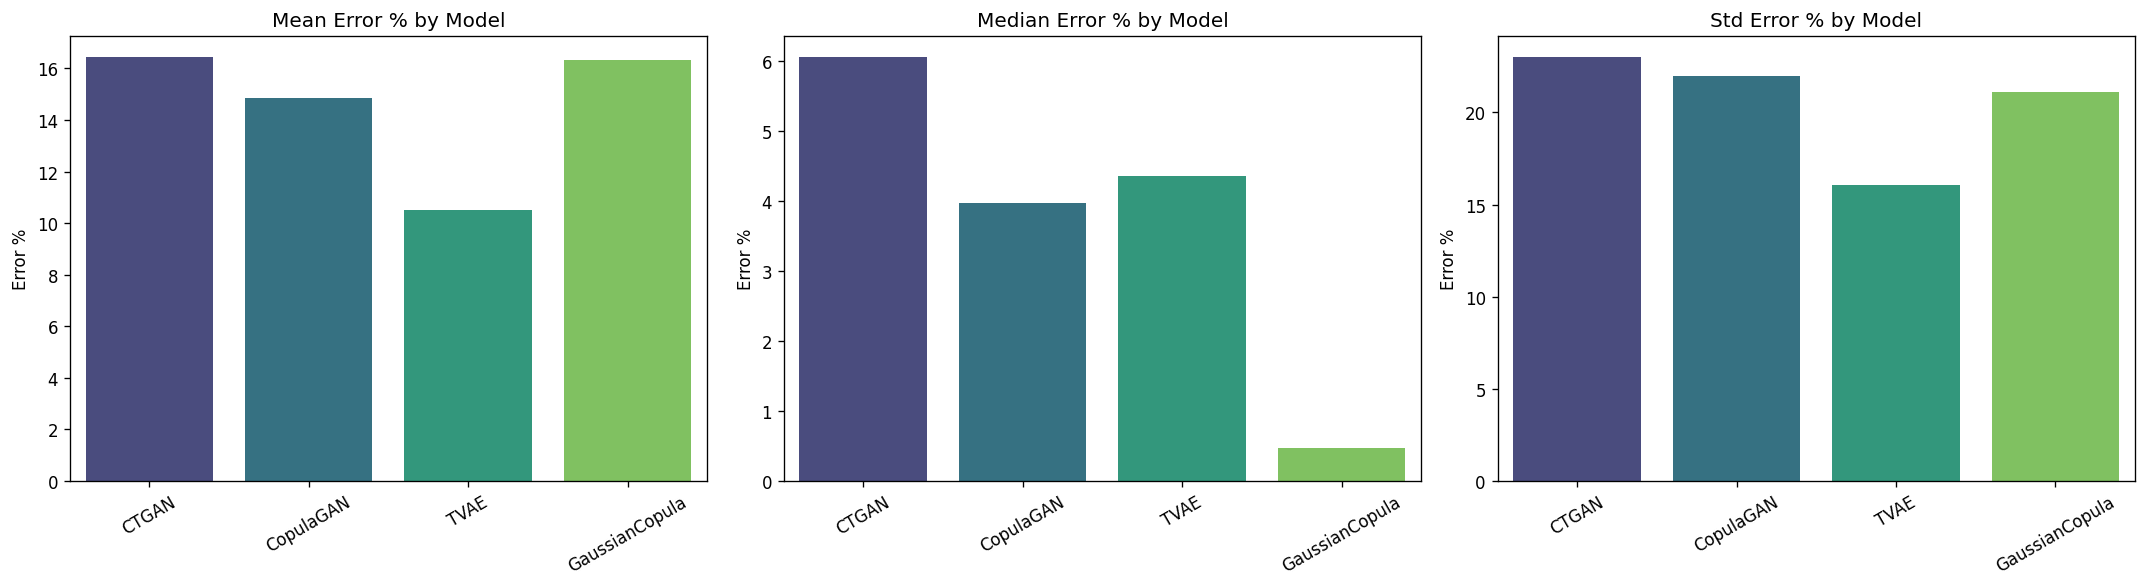

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = ad_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "Group" in num_cols:
    num_cols.remove("Group")

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


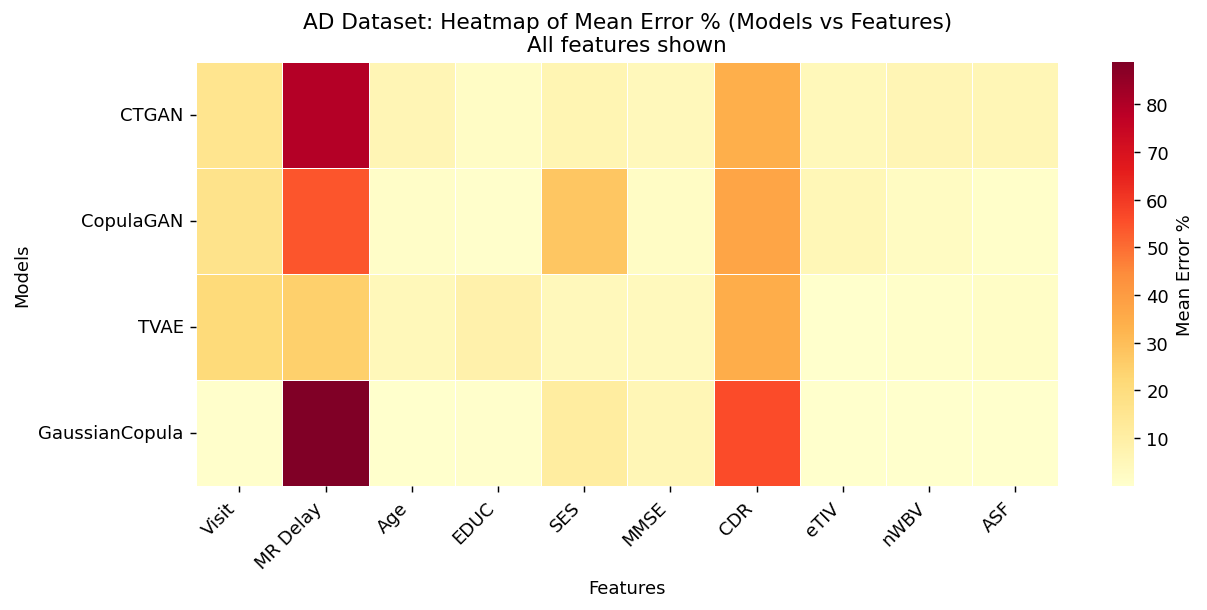

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"AD Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

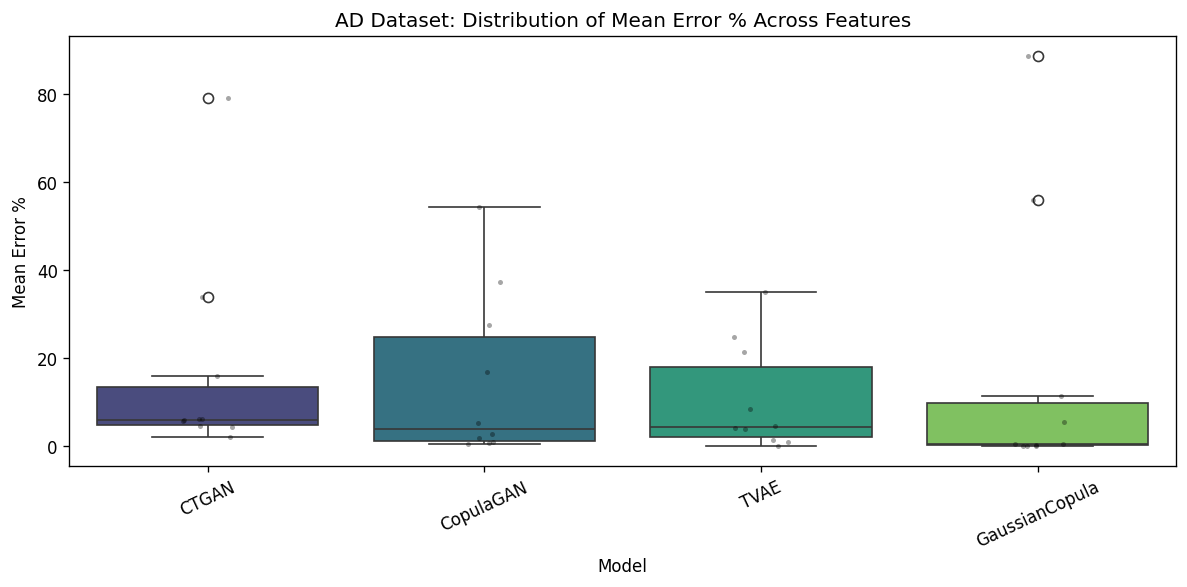

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("AD Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

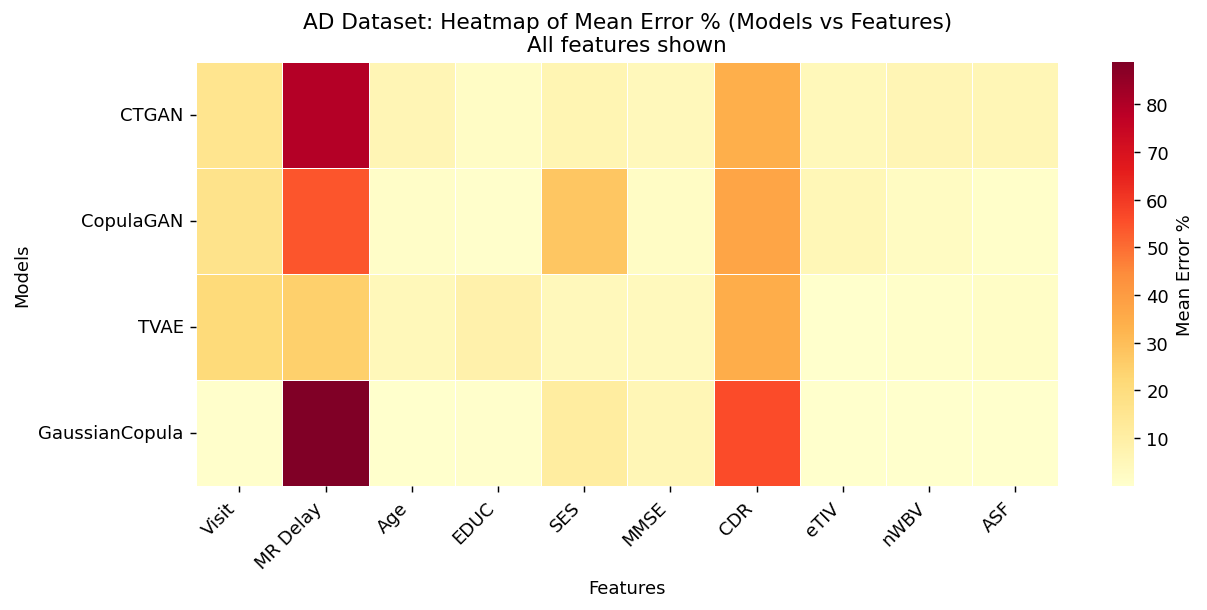

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"AD Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis

In [36]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_ad(real_df, synth_df, target="Group"):
    num_cols = [c for c in real_df.columns if c != target]

    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)

    return corr_df, target_df

In [37]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = ad_data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    corr_results, target_results = bivariate_quality_ad(
        real_df=real_df,
        synth_df=synth_df,
        target="Group"
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by Group class:")
    display(target_results.head(10))
    print("=" * 60)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results["delta_corr"].iloc[0] if not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results["delta_corr"].head(10).mean() if not corr_results.empty else None,
        "TopTargetDiff": target_results["delta_wasserstein"].iloc[0] if not target_results.empty else None,
        "MeanTop10TargetDiff": target_results["delta_wasserstein"].head(10).mean() if not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
0,Visit,MR Delay,0.993300
43,eTIV,ASF,0.893433
24,EDUC,SES,0.679394
35,MMSE,CDR,0.657032
22,Age,nWBV,0.511520
40,CDR,nWBV,0.375982
37,MMSE,nWBV,0.306856
32,SES,eTIV,0.256953
1,Visit,Age,0.256724
34,SES,ASF,0.256190


CTGAN - Features that differ most by Group class:


,feature,delta_wasserstein
6,CDR,0.283929
5,MMSE,0.131390
8,nWBV,0.110489
3,EDUC,0.046021
4,SES,0.035188
2,Age,0.034909
0,Visit,0.029537
7,eTIV,0.018632
9,ASF,0.012118
1,MR Delay,0.000419



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
0,Visit,MR Delay,0.321389
35,MMSE,CDR,0.265546
40,CDR,nWBV,0.155886
19,Age,MMSE,0.136996
37,MMSE,nWBV,0.115044
24,EDUC,SES,0.094155
9,MR Delay,Age,0.078956
38,MMSE,ASF,0.076271
33,SES,nWBV,0.067544
4,Visit,MMSE,0.066838


GaussianCopula - Features that differ most by Group class:


,feature,delta_wasserstein
6,CDR,0.184133
5,MMSE,0.121540
8,nWBV,0.058936
3,EDUC,0.058838
1,MR Delay,0.051323
4,SES,0.040946
0,Visit,0.018145
2,Age,0.006248
7,eTIV,0.005850
9,ASF,0.003682


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.993300,0.518739,0.283929,0.070263
1,CopulaGAN,1.025868,0.539303,0.273508,0.069148
2,TVAE,0.442916,0.335141,0.138181,0.044867
3,GaussianCopula,0.321389,0.137862,0.184133,0.054964


# 3 Multivariate Analysis

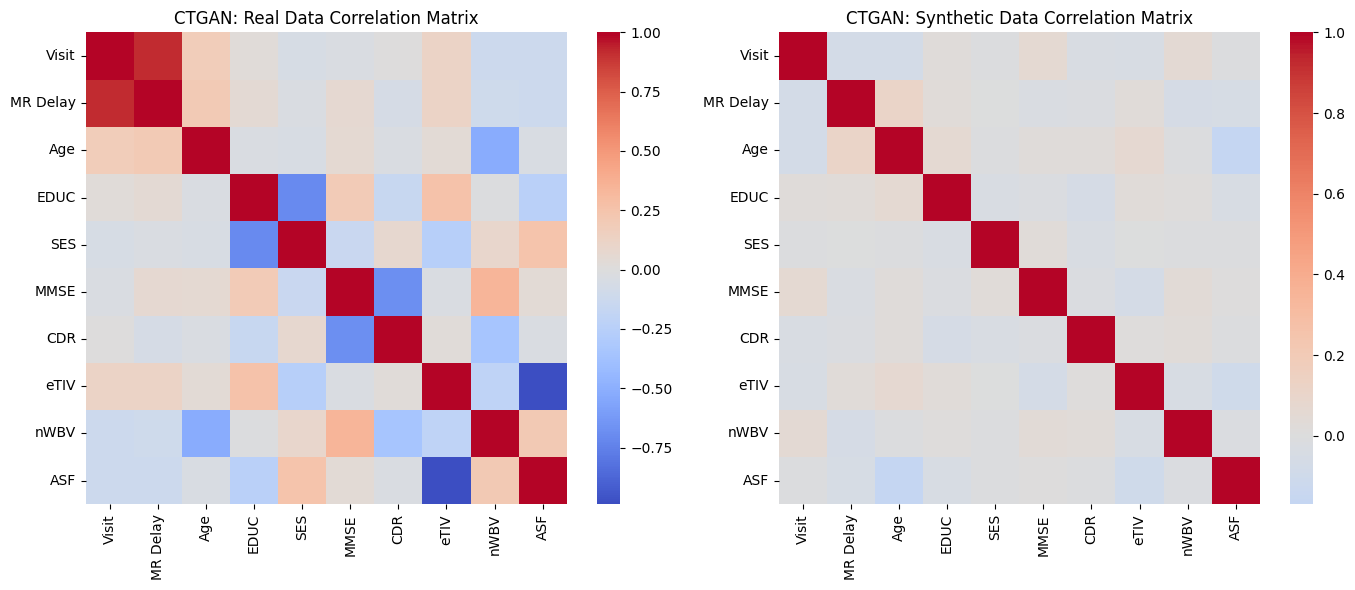

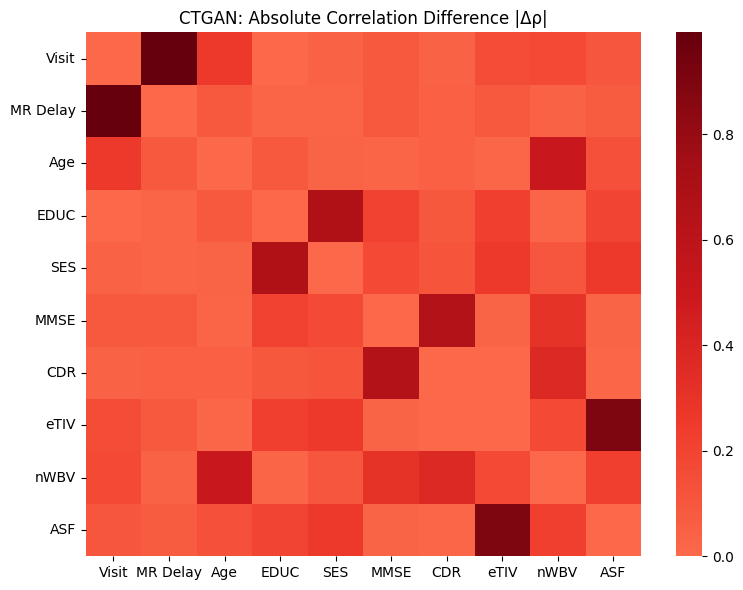

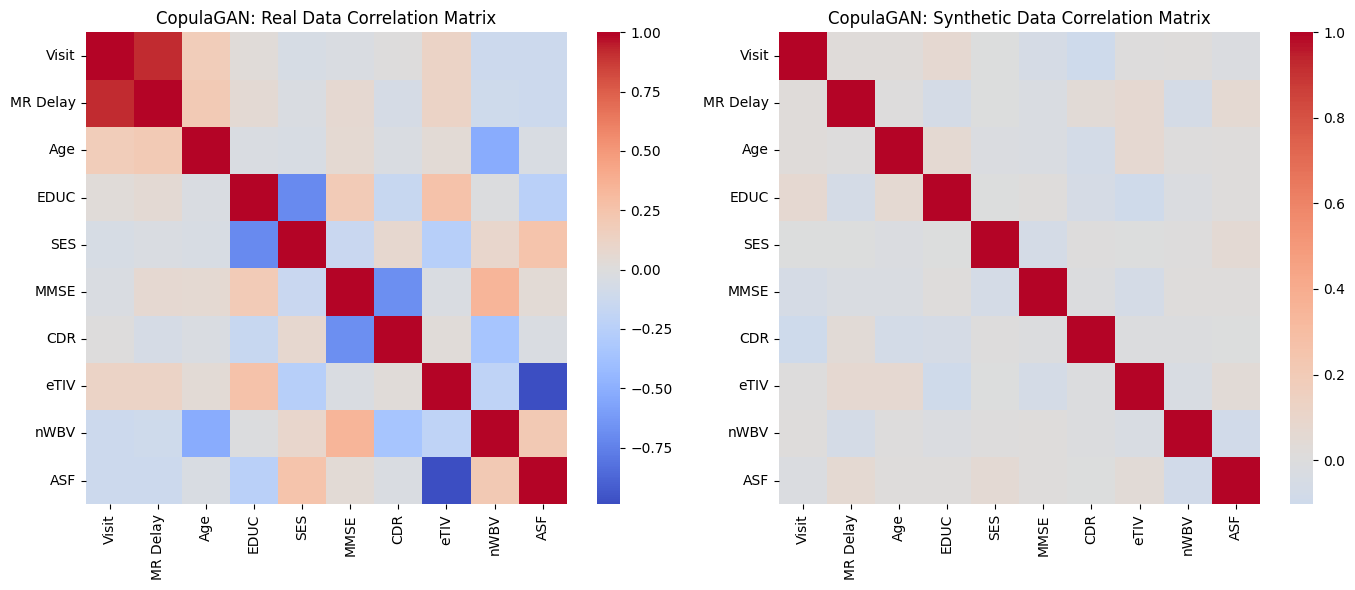

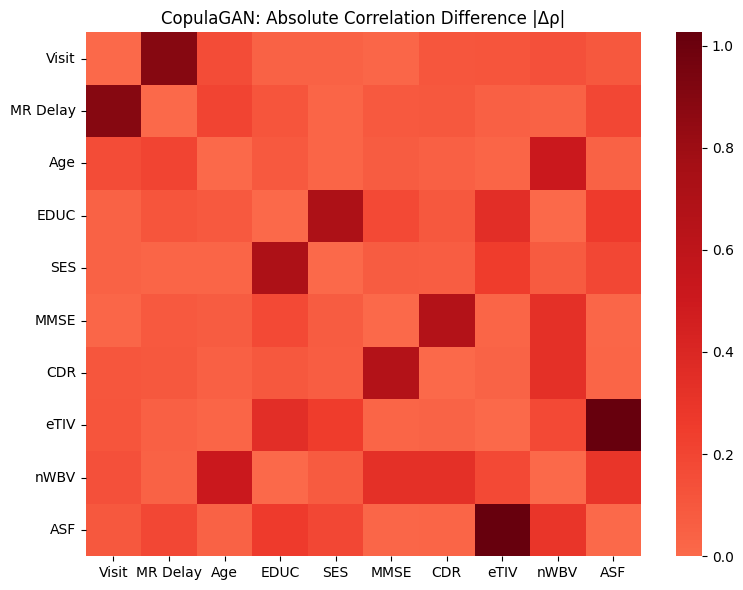

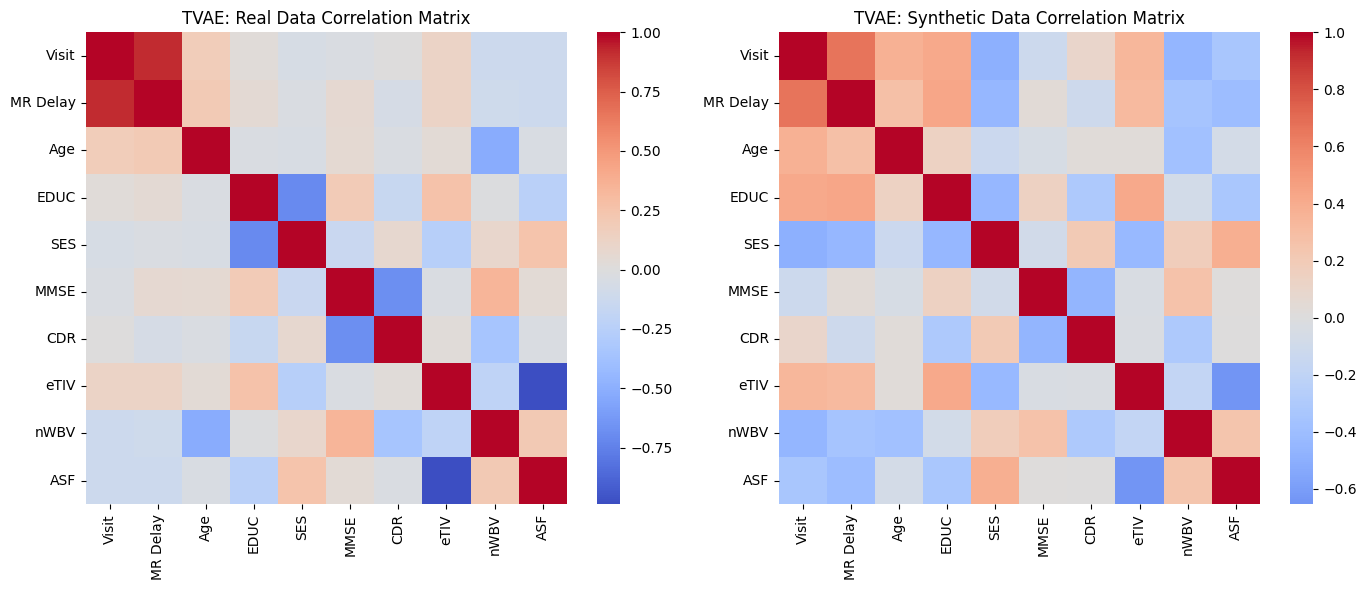

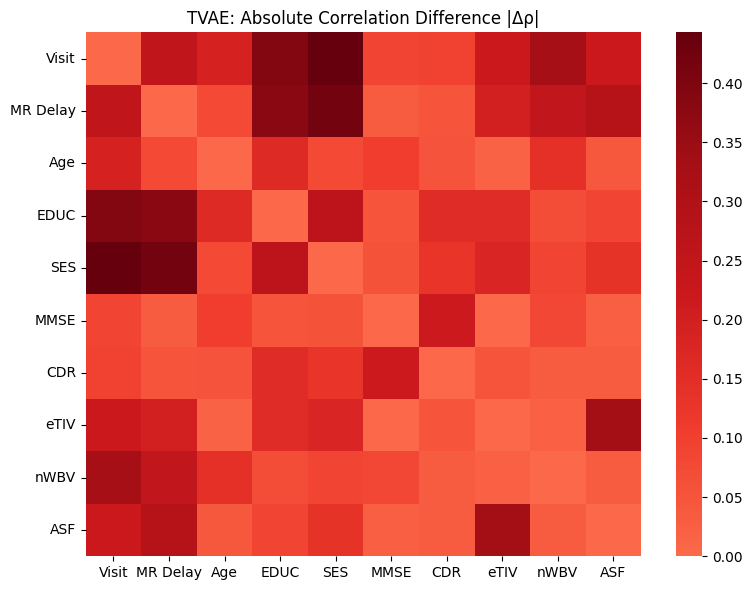

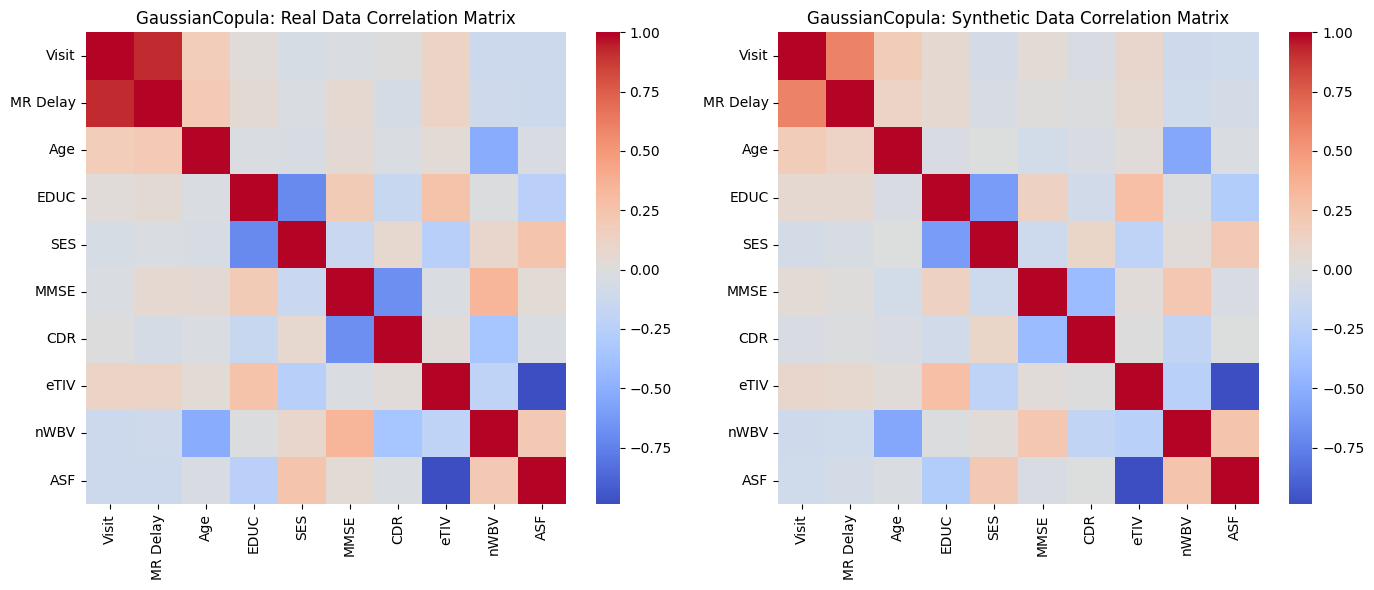

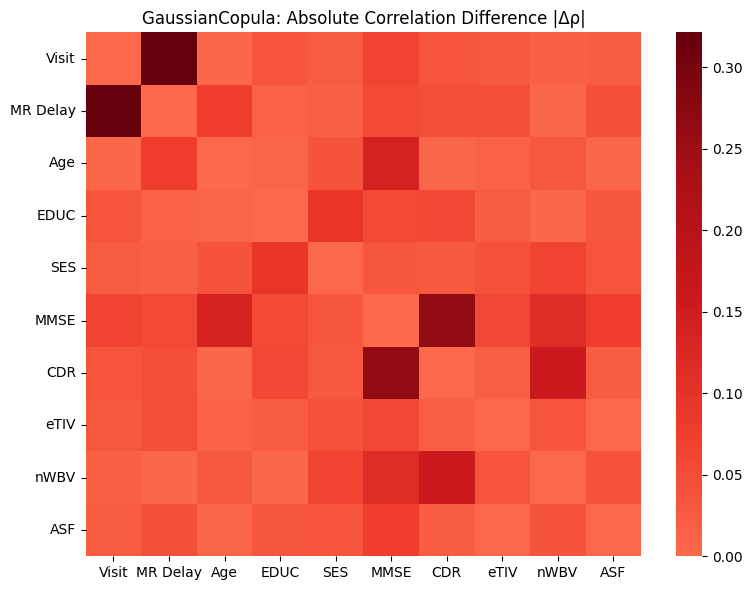

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = ad_data.copy()
num_cols = [c for c in real_df.columns if c != "Group"]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.077266


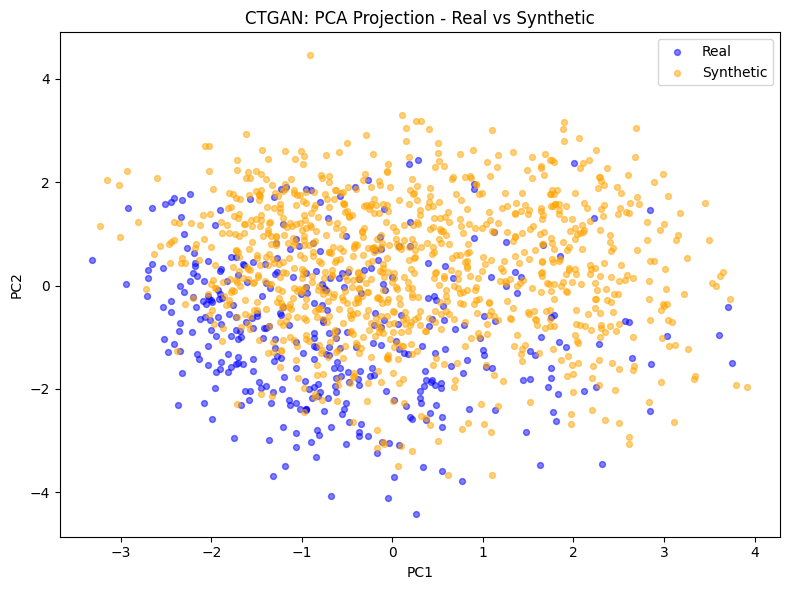

CTGAN - Two-Sample Classifier Accuracy: 0.9636

CopulaGAN - Global MMD (RBF): 0.040640


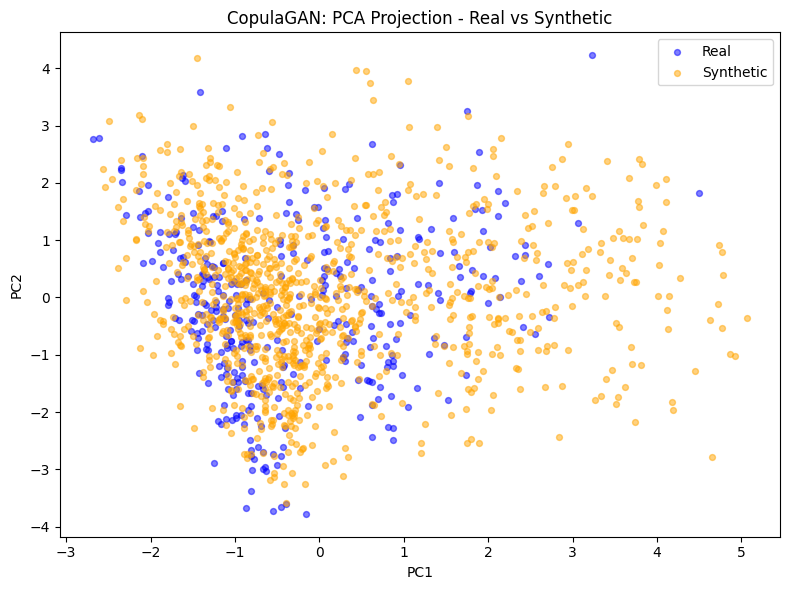

CopulaGAN - Two-Sample Classifier Accuracy: 0.9515

TVAE - Global MMD (RBF): 0.033075


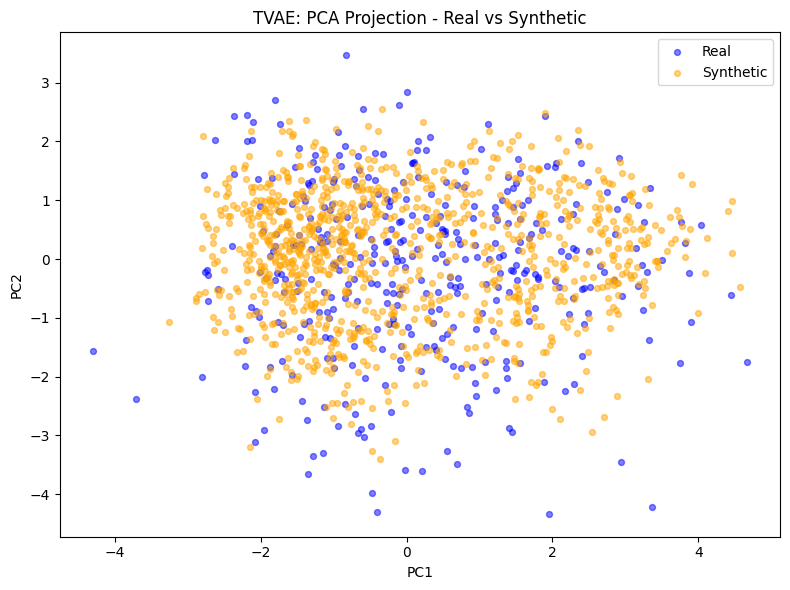

TVAE - Two-Sample Classifier Accuracy: 0.9563

GaussianCopula - Global MMD (RBF): 0.043953


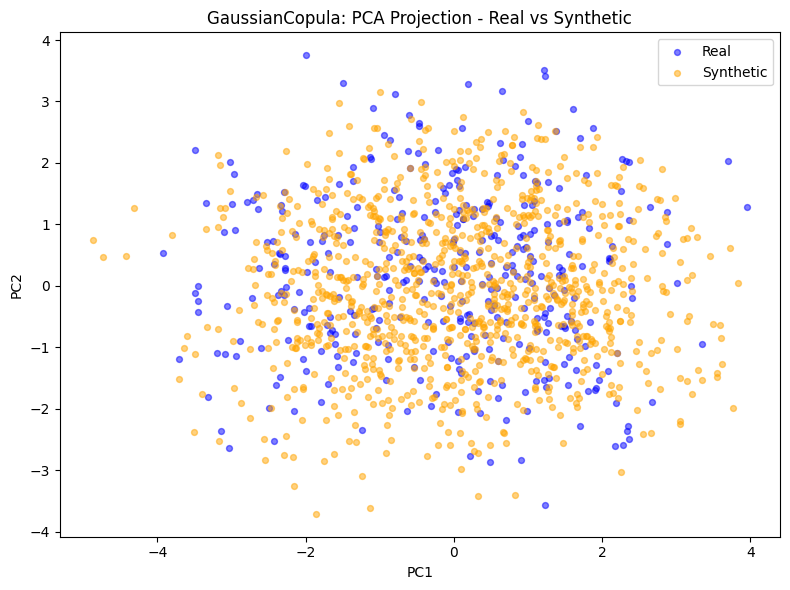

GaussianCopula - Two-Sample Classifier Accuracy: 0.9854

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,TVAE,0.033075,0.956311
1,CopulaGAN,0.040640,0.951456
2,GaussianCopula,0.043953,0.985437
3,CTGAN,0.077266,0.963592


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2))
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Group"

X_real_df = ad_data.drop(columns=[target_col], errors="ignore")
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = X_synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers

In [42]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

def evaluate_models(train_df, test_df, label_col="Group", models=models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

In [43]:
import pandas as pd

label_col = "Group"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=ad_data,
    test_df=ad_data,
    label_col="Group",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=ad_data,
        label_col="Group",
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.960000,0.957746,0.988265
0,LogReg,0.960000,0.957746,0.986486
9,MLP,0.946667,0.944444,0.977952
7,GradientBoost,0.960000,0.957746,0.973684
8,AdaBoost,0.960000,0.957746,0.967994
3,NaiveBayes,0.960000,0.957746,0.965861
5,RandomForest,0.960000,0.957746,0.965149
2,KNN,0.920000,0.911765,0.950213
1,SVM-RBF,0.960000,0.957746,0.948791
4,DecisionTree,0.946667,0.944444,0.946302


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
1,SVM-RBF,0.573333,0.529412,0.665363
7,GradientBoost,0.520000,0.454545,0.527027
0,LogReg,0.466667,0.230769,0.502845
6,ExtraTrees,0.480000,0.417910,0.502489
5,RandomForest,0.493333,0.500000,0.491821
2,KNN,0.493333,0.536585,0.479730
3,NaiveBayes,0.506667,0.412698,0.477952
9,MLP,0.480000,0.506329,0.476529
4,DecisionTree,0.440000,0.363636,0.438478
8,AdaBoost,0.466667,0.375000,0.416430


CTGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
8,AdaBoost,0.946667,0.945946,0.965505
6,ExtraTrees,0.840000,0.850000,0.951636
5,RandomForest,0.853333,0.860759,0.940967
0,LogReg,0.720000,0.764045,0.935989
7,GradientBoost,0.853333,0.849315,0.927454
3,NaiveBayes,0.906667,0.895522,0.913229
9,MLP,0.826667,0.826667,0.905405
1,SVM-RBF,0.840000,0.846154,0.851351
4,DecisionTree,0.800000,0.814815,0.801209
2,KNN,0.693333,0.656716,0.752845


GaussianCopula - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
7,KNN,0.920000,0.911765,0.950213,0.693333,0.656716,0.752845,0.197368,0.255048,0.226667,GaussianCopula
9,DecisionTree,0.946667,0.944444,0.946302,0.800000,0.814815,0.801209,0.145092,0.129630,0.146667,GaussianCopula
8,SVM-RBF,0.960000,0.957746,0.948791,0.840000,0.846154,0.851351,0.097440,0.111593,0.120000,GaussianCopula
2,MLP,0.946667,0.944444,0.977952,0.826667,0.826667,0.905405,0.072546,0.117778,0.120000,GaussianCopula
5,NaiveBayes,0.960000,0.957746,0.965861,0.906667,0.895522,0.913229,0.052632,0.062224,0.053333,GaussianCopula
1,LogReg,0.960000,0.957746,0.986486,0.720000,0.764045,0.935989,0.050498,0.193702,0.240000,GaussianCopula
3,GradientBoost,0.960000,0.957746,0.973684,0.853333,0.849315,0.927454,0.046230,0.108431,0.106667,GaussianCopula
0,ExtraTrees,0.960000,0.957746,0.988265,0.840000,0.850000,0.951636,0.036629,0.107746,0.120000,GaussianCopula
6,RandomForest,0.960000,0.957746,0.965149,0.853333,0.860759,0.940967,0.024182,0.096987,0.106667,GaussianCopula
4,AdaBoost,0.960000,0.957746,0.967994,0.946667,0.945946,0.965505,0.002489,0.011801,0.013333,GaussianCopula


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
3,TVAE,0.024858
2,GaussianCopula,0.072511
0,CTGAN,0.469203
1,CopulaGAN,0.578983



CTGAN - TSTR


,Model,Accuracy,F1,AUC
1,SVM-RBF,0.573333,0.529412,0.665363
7,GradientBoost,0.520000,0.454545,0.527027
0,LogReg,0.466667,0.230769,0.502845
6,ExtraTrees,0.480000,0.417910,0.502489
5,RandomForest,0.493333,0.500000,0.491821
2,KNN,0.493333,0.536585,0.479730
3,NaiveBayes,0.506667,0.412698,0.477952
9,MLP,0.480000,0.506329,0.476529
4,DecisionTree,0.440000,0.363636,0.438478
8,AdaBoost,0.466667,0.375000,0.416430


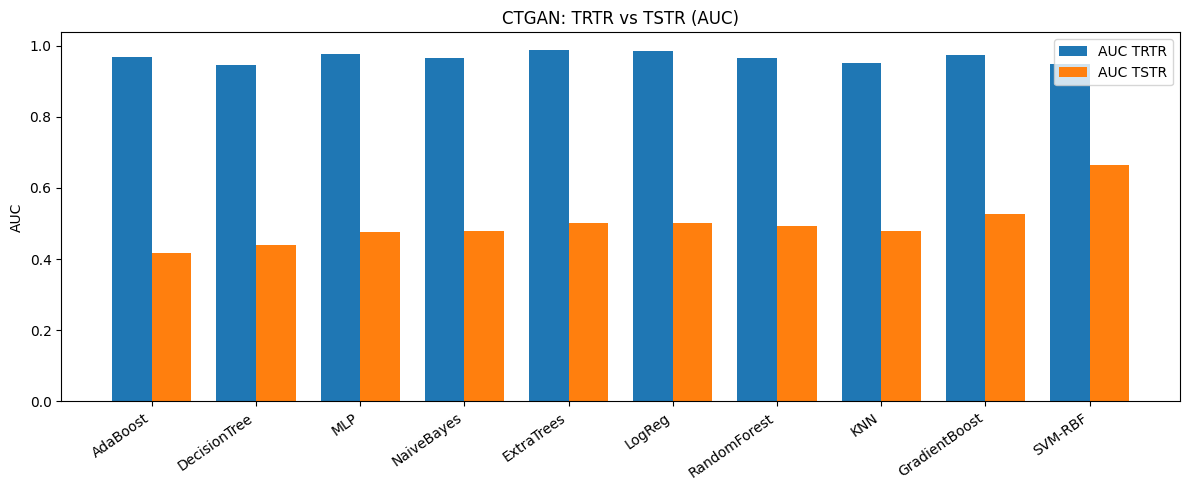

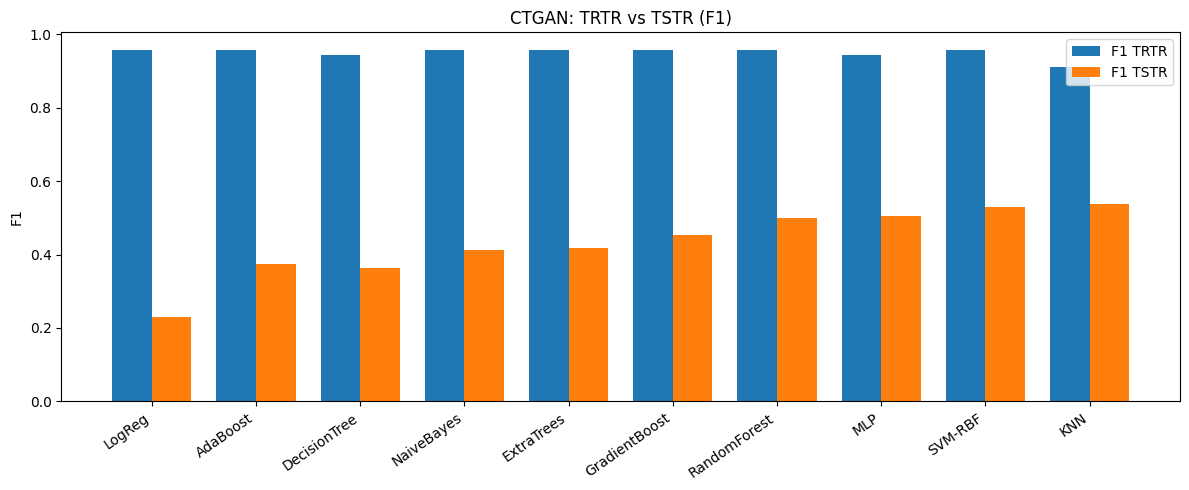

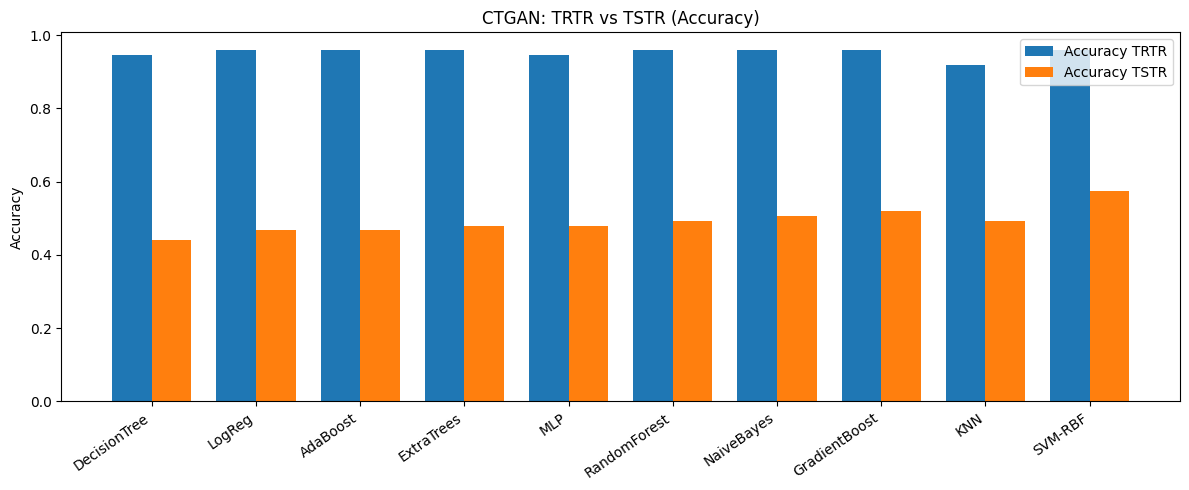

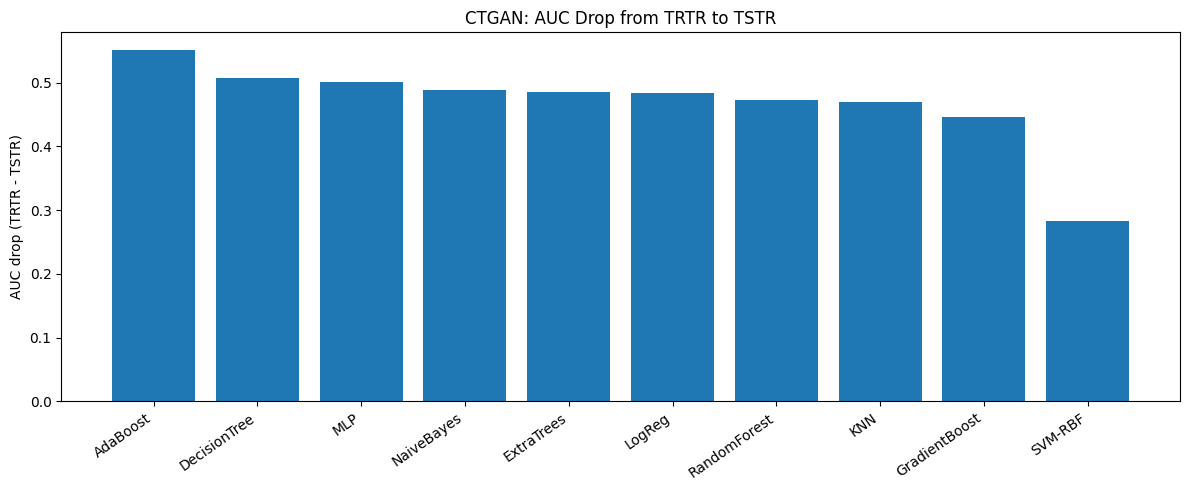


CopulaGAN - TSTR


,Model,Accuracy,F1,AUC
1,SVM-RBF,0.426667,0.245614,0.646159
0,LogReg,0.533333,0.444444,0.516358
3,NaiveBayes,0.426667,0.338462,0.411807
9,MLP,0.373333,0.433735,0.401849
7,GradientBoost,0.426667,0.338462,0.361309
4,DecisionTree,0.346667,0.346667,0.346728
2,KNN,0.373333,0.389610,0.338549
8,AdaBoost,0.360000,0.200000,0.337127
6,ExtraTrees,0.373333,0.338028,0.287340
5,RandomForest,0.333333,0.264706,0.233642


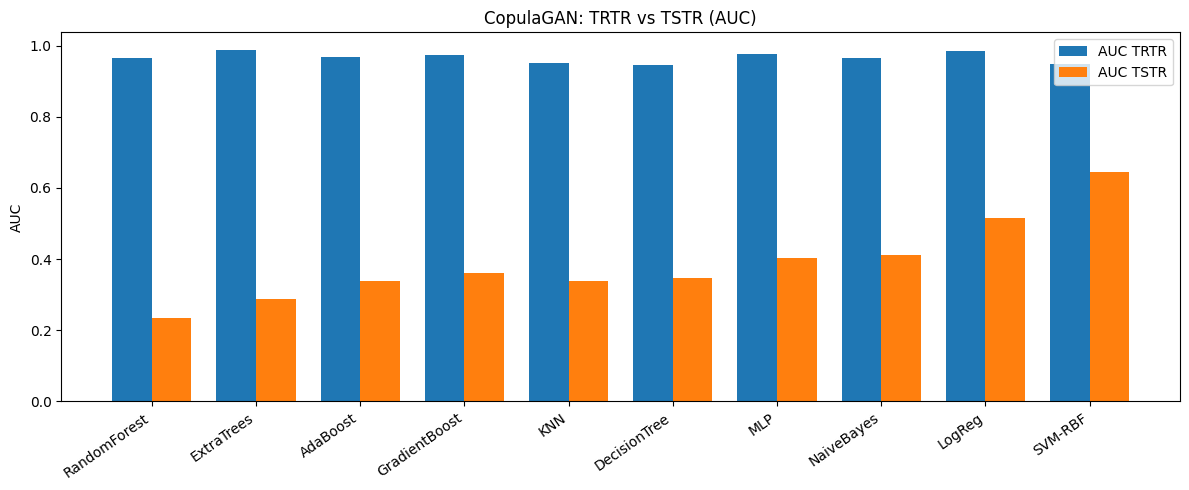

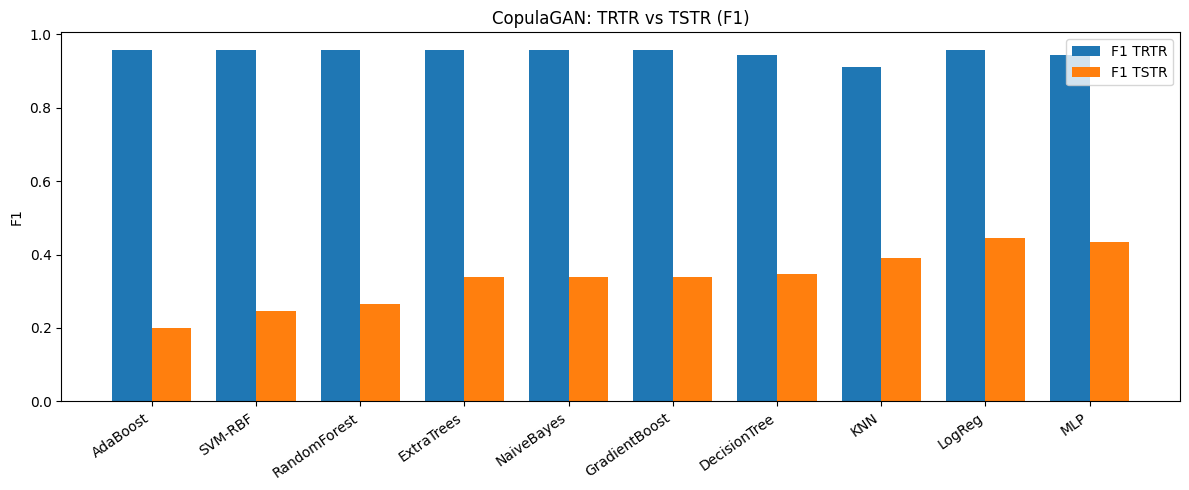

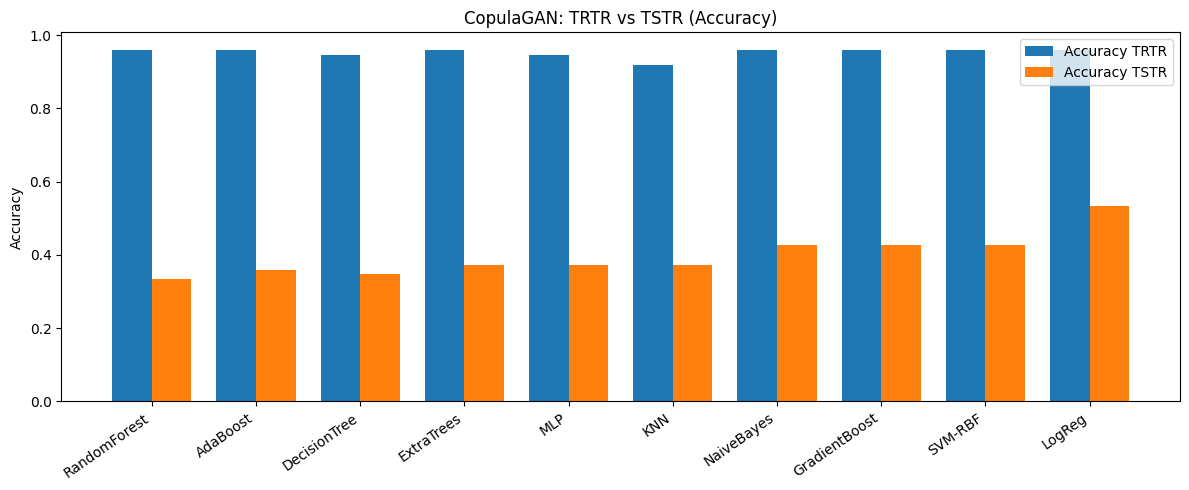

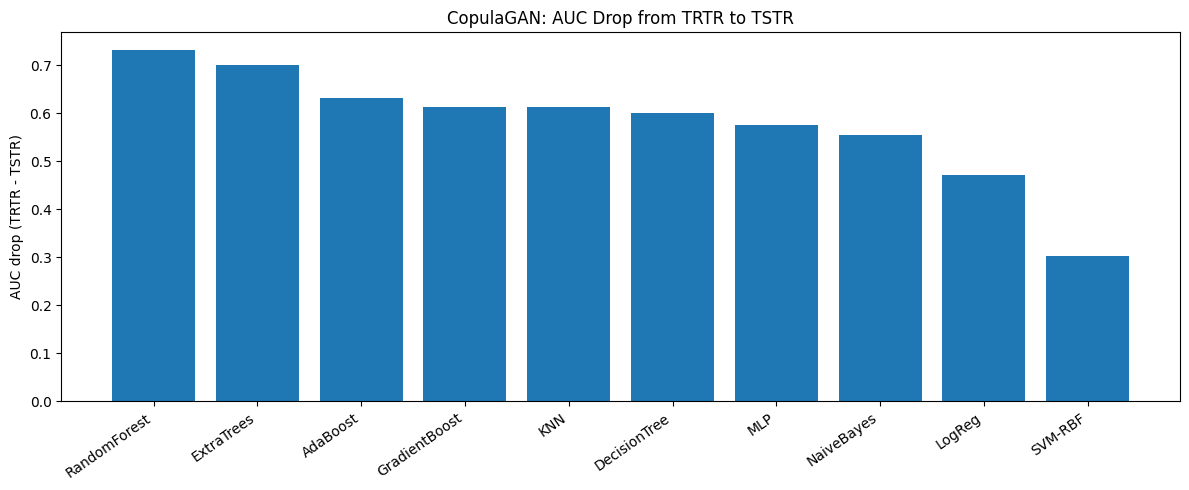


TVAE - TSTR


,Model,Accuracy,F1,AUC
8,AdaBoost,0.866667,0.875000,0.981863
7,GradientBoost,0.880000,0.888889,0.979374
6,ExtraTrees,0.906667,0.906667,0.970839
5,RandomForest,0.866667,0.875000,0.969417
9,MLP,0.906667,0.909091,0.968706
3,NaiveBayes,0.960000,0.957746,0.957326
1,SVM-RBF,0.933333,0.927536,0.942390
0,LogReg,0.853333,0.860759,0.934566
2,KNN,0.880000,0.869565,0.915363
4,DecisionTree,0.800000,0.827586,0.802276


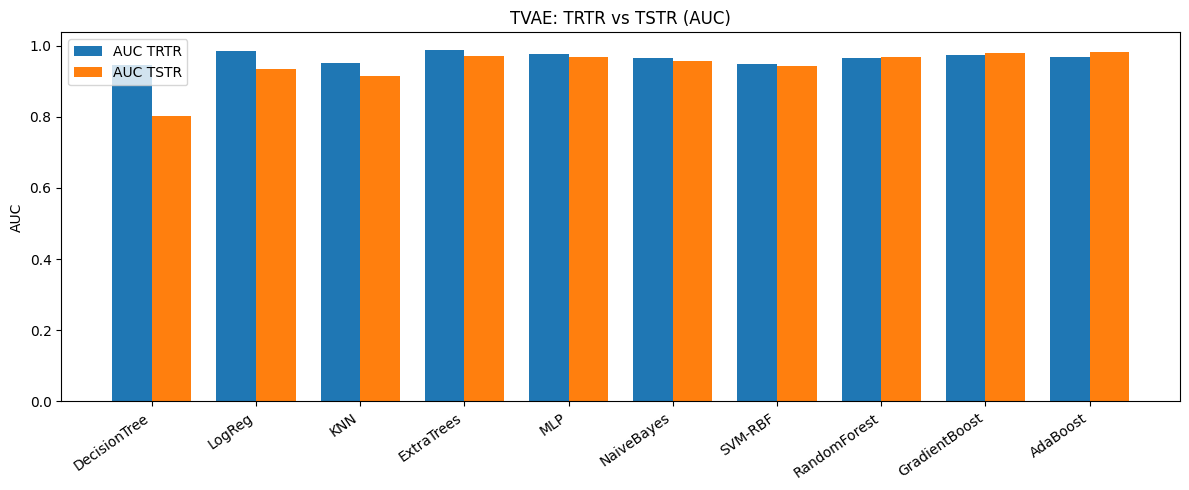

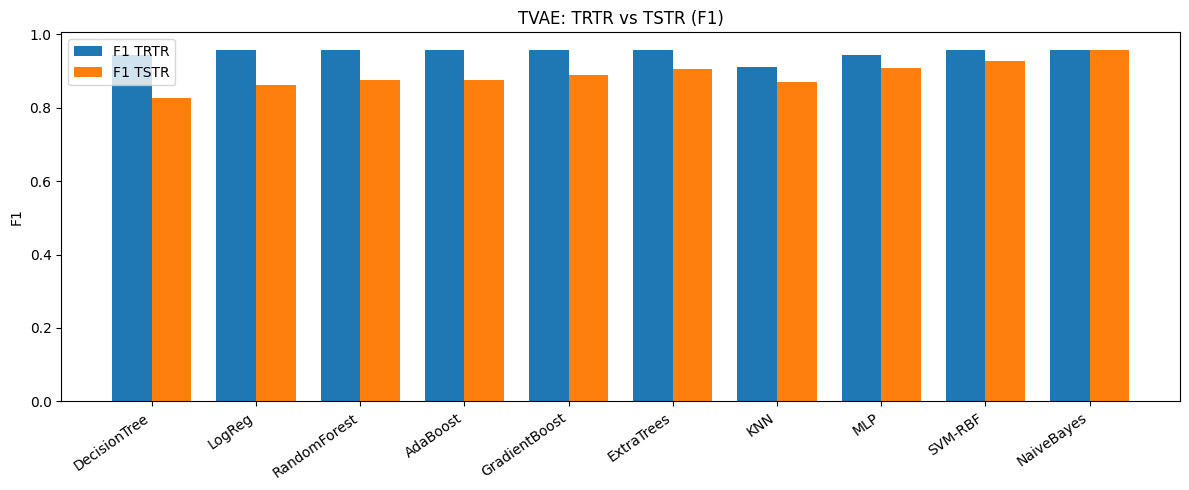

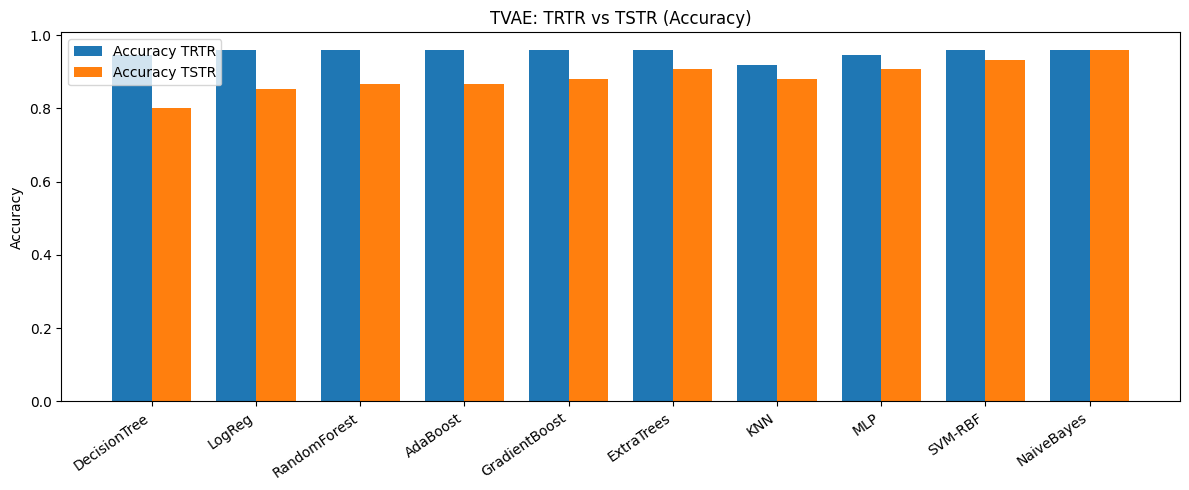

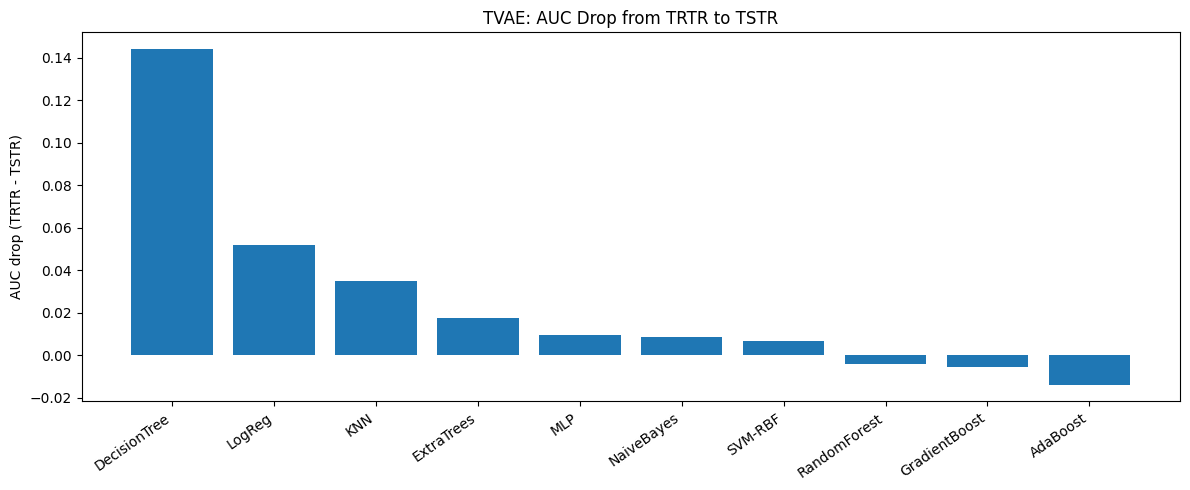

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "Group"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=ad_data,
    test_df=ad_data,
    label_col="Group",
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=ad_data,
        label_col="Group",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "Group"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=ad_data,
    test_df=ad_data,
    label_col="Group",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen],
        test_df=ad_data,
        label_col="Group",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests

Outlier-count comparison (IQR rule) between real and synthetic numeric features — same metric as Adult / Other GAN / Diffusion notebooks (`Avg_Abs_Diff_Outlier_Count`).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumes:
# - ad_data
# - synthetic_datasets = {"CTGAN": df, "CopulaGAN": df, "TVAE": df, "GaussianCopula": df}

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = ad_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "Group" in num_cols:
    num_cols.remove("Group")

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols],
    })
    feat_df["Abs_Diff_Outlier_Count"] = (
        feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]
    ).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max(),
    })

outlier_summary_df = (
    pd.DataFrame(rows)
    .sort_values("Avg_Abs_Diff_Outlier_Count")
    .reset_index(drop=True)
)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(
    data=outlier_summary_df,
    x="Model",
    y="Avg_Abs_Diff_Outlier_Count",
    palette="viridis",
)
plt.title("AD Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CTGAN,7.1,7.5,21.0
1,CopulaGAN,11.7,5.0,64.0
2,TVAE,14.3,5.5,78.0
3,GaussianCopula,14.8,3.5,59.0


# 6. Cosine Similarity with Hungraian Mapping

In [ ]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

real_data = ad_data.copy()

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(real_data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(real_data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(real_data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(real_data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(real_data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[real_data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = real_data.select_dtypes(include=[np.number]).columns
real_matrix = normalize_rows(real_data[num_cols].to_numpy())

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy())
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.879012  0.596957  0.992699  0.997556  0.866073  0.999978  0.870704   
R2   0.962896  0.760202  0.994605  0.987347  0.955448  0.975019  0.958167   
R3   0.879025  0.596958  0.992706  0.997575  0.866078  0.999975  0.870699   
R4   0.982766  0.814086  0.981773  0.969845  0.977586  0.951880  0.979513   
R5   0.941742  0.995803  0.752347  0.715390  0.950385  0.667738  0.947477   
R6   0.879038  0.596773  0.992502  0.997767  0.865864  0.999427  0.870134   
R7   0.996955  0.872121  0.955113  0.937900  0.994390  0.912384  0.994991   
R8   0.879059  0.596969  0.992726  0.997647  0.866101  0.999969  0.870677   
R9   0.999200  0.922692  0.915159  0.891842  0.999904  0.860081  0.999727   
R10  0.966659  0.984626  0.805006  0.771561  0.973154  0.727865  0.970951   

           S8        S9       S10  
R1   0.428129  0.949759  0.799427  
R2   0.618106  0.995544  0.912

,avg_cosine,max_cosine
CTGAN,0.896182,0.999999
CopulaGAN,0.880976,0.999999
TVAE,0.901119,1.000000
GaussianCopula,0.906178,1.000000


In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = ad_data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


CTGAN - Top 10 Real -> Synthetic Matchings
01. R291 -> S141   cosine similarity = 1.0000
02. R155 -> S292   cosine similarity = 1.0000
03. R69 -> S50   cosine similarity = 1.0000
04. R157 -> S55   cosine similarity = 1.0000
05. R188 -> S291   cosine similarity = 1.0000
06. R228 -> S138   cosine similarity = 1.0000
07. R85 -> S39   cosine similarity = 1.0000
08. R246 -> S55   cosine similarity = 1.0000
09. R111 -> S246   cosine similarity = 1.0000
10. R352 -> S292   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R226 -> S161   cosine similarity = 1.0000
02. R224 -> S23   cosine similarity = 1.0000
03. R46 -> S180   cosine similarity = 1.0000
04. R323 -> S209   cosine similarity = 1.0000
05. R357 -> S313   cosine similarity = 1.0000
06. R8 -> S345   cosine similarity = 1.0000
07. R370 -> S159   cosine similarity = 1.0000
08. R178 -> S173   cosine similarity = 1.0000
09. R172 -> S161   cosine similarity = 1.0000
10. R272 -> S30   cosine similarity = 1.0000

In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = ad_data.copy()

model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN": CTGANSynthesizer,
    "CopulaGAN": CopulaGANSynthesizer,
    "TVAE": TVAESynthesizer,
}

models = {}
synthetic_tables = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(real_df)
    models[name] = model
    synthetic_tables[name] = model.sample(num_rows=len(real_df))[real_df.columns]

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9241

R117 <-> S217   cosine similarity = 1.0000
R259 <-> S284   cosine similarity = 1.0000
R157 <-> S232   cosine similarity = 1.0000
R11 <-> S150   cosine similarity = 1.0000
R238 <-> S306   cosine similarity = 1.0000
R251 <-> S372   cosine similarity = 1.0000
R296 <-> S162   cosine similarity = 1.0000
R16 <-> S120   cosine similarity = 1.0000
R54 <-> S1   cosine similarity = 1.0000
R341 <-> S322   cosine similarity = 1.0000

CTGAN: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9959

R306 <-> S210   cosine similarity = 1.0000
R58 <-> S293   cosine similarity = 1.0000
R54 <-> S217   cosine similarity = 1.0000
R34 <-> S66   cosine similarity = 1.0000
R321 <-> S122   cosine similarity = 1.0000
R135 <-> S113   cosine similarity = 1.0000
R282 <-> S

In [ ]:
import pandas as pd
import numpy as np

real_df = ad_data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_AD.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            continue
        if model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Hungarian_Matchings_All_Models_AD.xlsx


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
0,CTGAN,373,0.995876,0.998715,0.977256,0.999999
2,TVAE,373,0.985688,0.998979,0.925931,1.000000
1,CopulaGAN,373,0.969223,0.966097,0.867402,0.999999
3,GaussianCopula,373,0.924080,0.940347,0.760445,1.000000


# 7. Mahalanobis distance with Hungrain Mapping

In [ ]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

data_numeric = ad_data.select_dtypes(include=[np.number]).dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (11,), Inv_cov shape: (11, 11)


In [ ]:
mahalanobis_results = {}
num_cols = ad_data.select_dtypes(include=[np.number]).columns.tolist()

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=float)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
GaussianCopula,4.431651,4.010306,1.690880,1.837083,11.529041
TVAE,6.501455,5.866706,3.061232,2.035390,20.120418
CTGAN,12.098402,10.524966,6.172250,2.825828,32.913294
CopulaGAN,12.929126,11.977902,5.625374,2.169728,37.915941


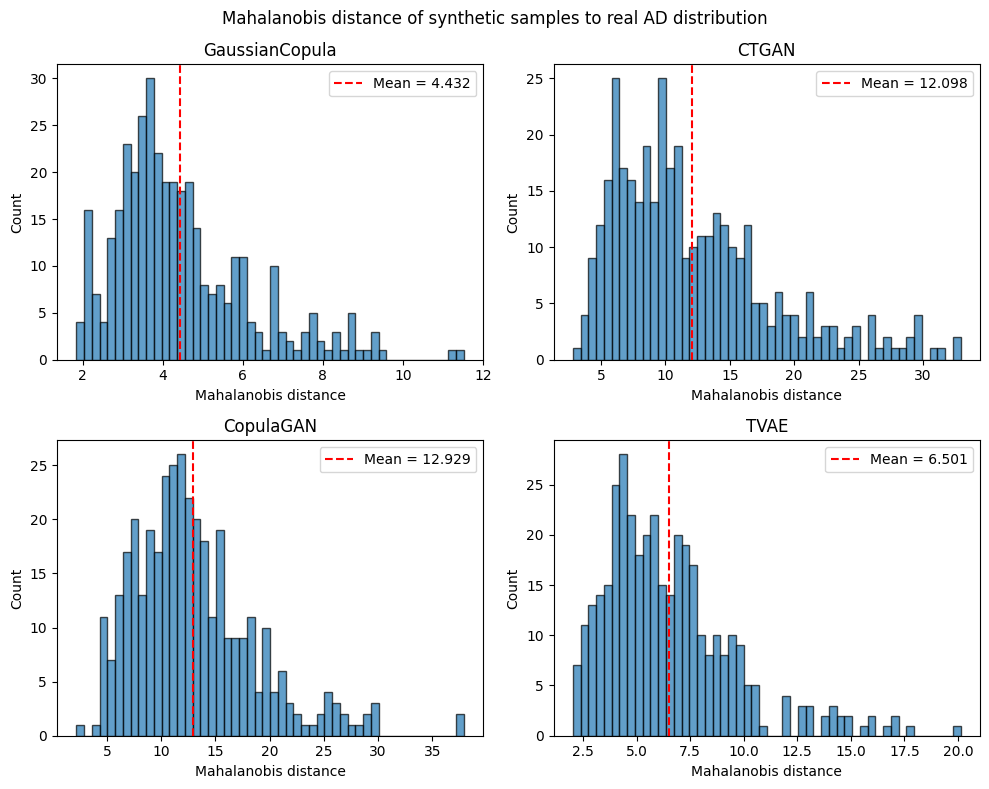

In [ ]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real AD distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_ad_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = ad_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = ad_data[num_cols].to_numpy(dtype=float)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
GaussianCopula,3.645720,3.434888,1.830990,10.614454
TVAE,5.391572,4.747187,3.137126,20.193365
CTGAN,10.895524,9.391240,6.076669,31.995548
CopulaGAN,11.505781,10.430780,5.639922,36.621683


In [ ]:
# Greedy mapping 
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = ad_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = ad_data[num_cols].to_numpy(dtype=float)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    total_g, mean_g, _ = greedy_one_to_one_matching(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Greedy total": total_g,
        "Hungarian total": h_total,
        "Greedy mean": mean_g,
        "Hungarian mean": h_mean,
        "Total diff (Greedy - Hungarian)": total_g - h_total,
        "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (Mahalanobis distance):")
display(greedy_summary)

print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
GaussianCopula,1466.736334,3.932269
CTGAN,4168.726224,11.176210
CopulaGAN,4398.523134,11.792287
TVAE,2092.793969,5.610708



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
GaussianCopula,1466.736334,1359.853669,3.932269,3.645720,106.882665,0.286549
CTGAN,4168.726224,4064.030328,11.176210,10.895524,104.695896,0.280686
CopulaGAN,4398.523134,4291.656490,11.792287,11.505781,106.866644,0.286506
TVAE,2092.793969,2011.056353,5.610708,5.391572,81.737616,0.219136


In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=float)
    S = synth_df[feature_cols].to_numpy(dtype=float)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=float), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = ad_data.copy()

feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "Group"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=float)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 10
GaussianCopula: avg matched Mahalanobis distance = 3.3620
CTGAN: avg matched Mahalanobis distance = 10.7084
CopulaGAN: avg matched Mahalanobis distance = 11.1150
TVAE: avg matched Mahalanobis distance = 5.2639


In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != "Group"]
real_df = ad_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
hungarian_results = {}

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    hungarian_results[model_name] = {"row_ind": row_ind, "col_ind": col_ind, "dists": dists}

    order = np.argsort(dists)
    top_k = min(20, len(order))

    print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
    for rank, k in enumerate(order[:top_k], 1):
        print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")


CTGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R188 -> S152   distance = 1.9155
02. R146 -> S209   distance = 2.0644
03. R286 -> S27   distance = 2.3085
04. R59 -> S116   distance = 2.3426
05. R87 -> S4   distance = 2.4292
06. R47 -> S274   distance = 2.5482
07. R321 -> S329   distance = 2.7067
08. R350 -> S81   distance = 2.8212
09. R165 -> S240   distance = 2.8215
10. R88 -> S157   distance = 2.8683
11. R250 -> S259   distance = 2.8748
12. R53 -> S155   distance = 2.8803
13. R84 -> S8   distance = 2.9051
14. R148 -> S202   distance = 2.9463
15. R127 -> S309   distance = 3.0075
16. R119 -> S158   distance = 3.0905
17. R198 -> S54   distance = 3.1657
18. R352 -> S66   distance = 3.2109
19. R307 -> S83   distance = 3.2125
20. R229 -> S222   distance = 3.2415

CopulaGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R133 -> S175   distance = 0.9256
02. R68 -> S91   distance = 2.2236
03. R152 -> S22   distance = 2.4813
04. R30 -> S289   distance = 

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != "Group"]
real_df = ad_data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S217   distance = 25.7101
R2 -> S7   distance = 20.9406
R3 -> S299   distance = 8.2167
R4 -> S19   distance = 17.8080
R5 -> S234   distance = 10.1655
R6 -> S282   distance = 27.7397
R7 -> S17   distance = 24.1508
R8 -> S303   distance = 10.9645
R9 -> S318   distance = 6.1683
R10 -> S266   distance = 12.9361
R11 -> S5   distance = 5.8654
R12 -> S74   distance = 7.1960
R13 -> S224   distance = 6.7344
R14 -> S292   distance = 10.1686
R15 -> S225   distance = 22.5009
R16 -> S279   distance = 8.6892
R17 -> S120   distance = 6.3896
R18 -> S24   distance = 4.4409
R19 -> S140   distance = 4.3061
R20 -> S300   distance = 12.4635

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S13   distance = 16.7300
R2 -> S346   distance = 14.5028
R3 -> S119   distance = 6.0926
R4 -> S294   distance = 14.2741
R5 -> S303   distance = 6.2595
R6 -> S132   distance = 7.9324
R7 -> S158   distance = 16.7648
R8 -> S161   distance = 3.8178
R9 -> S331   distance = 4

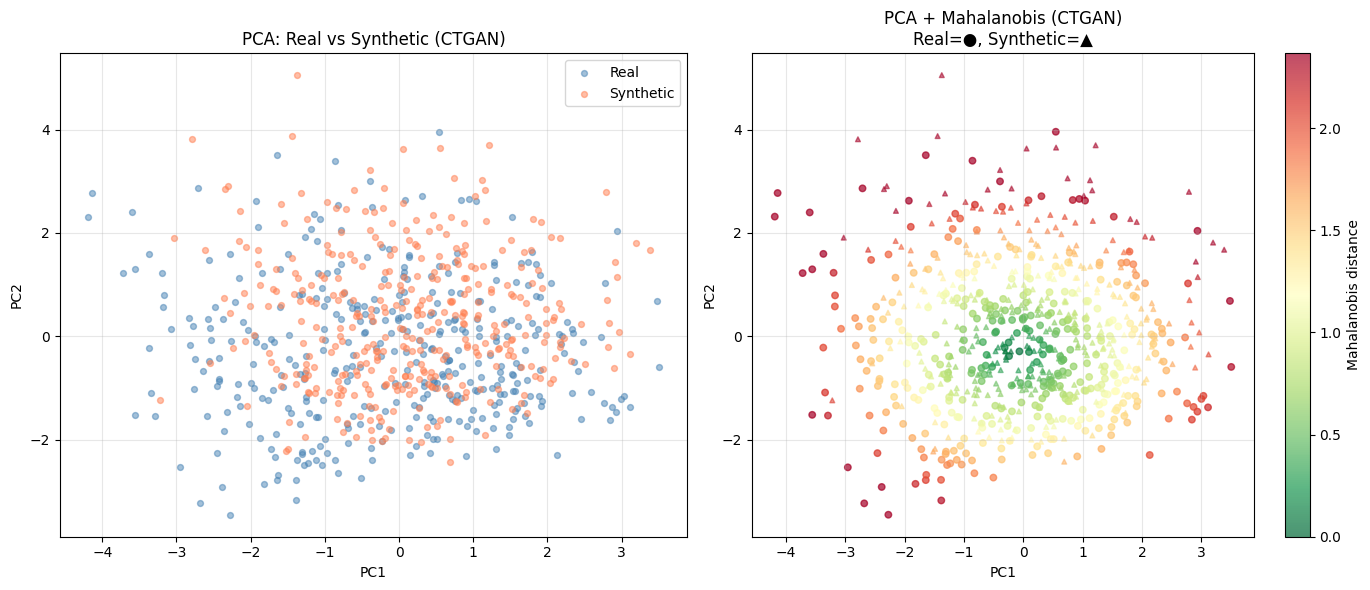

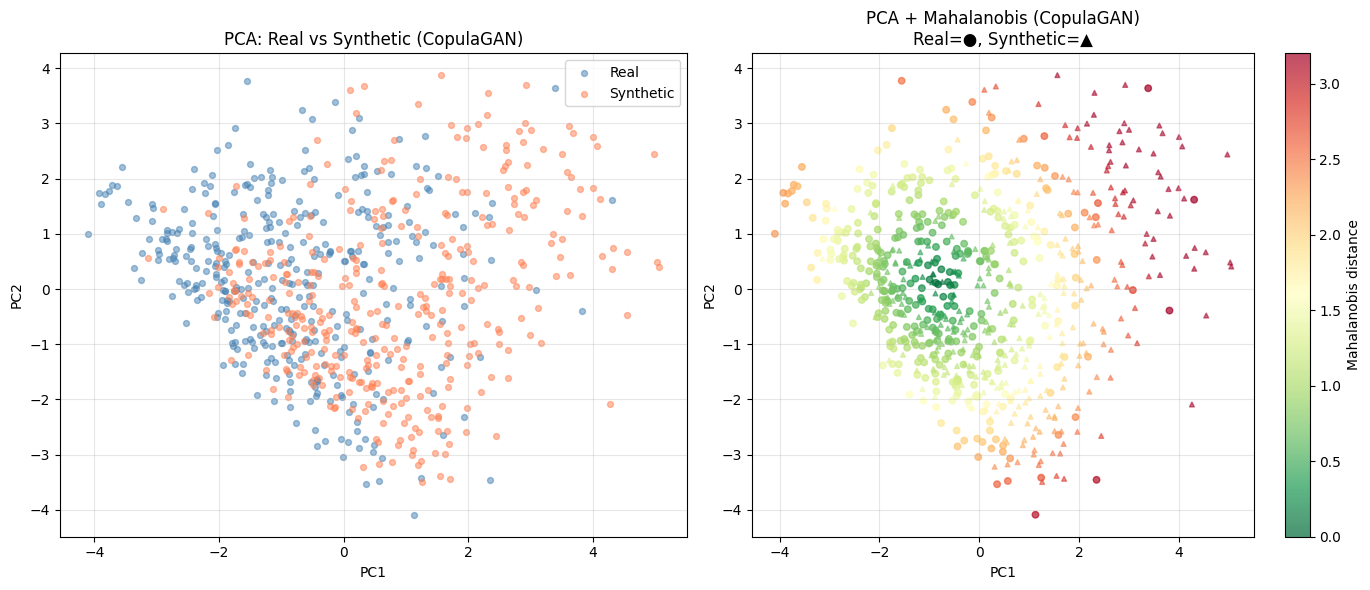

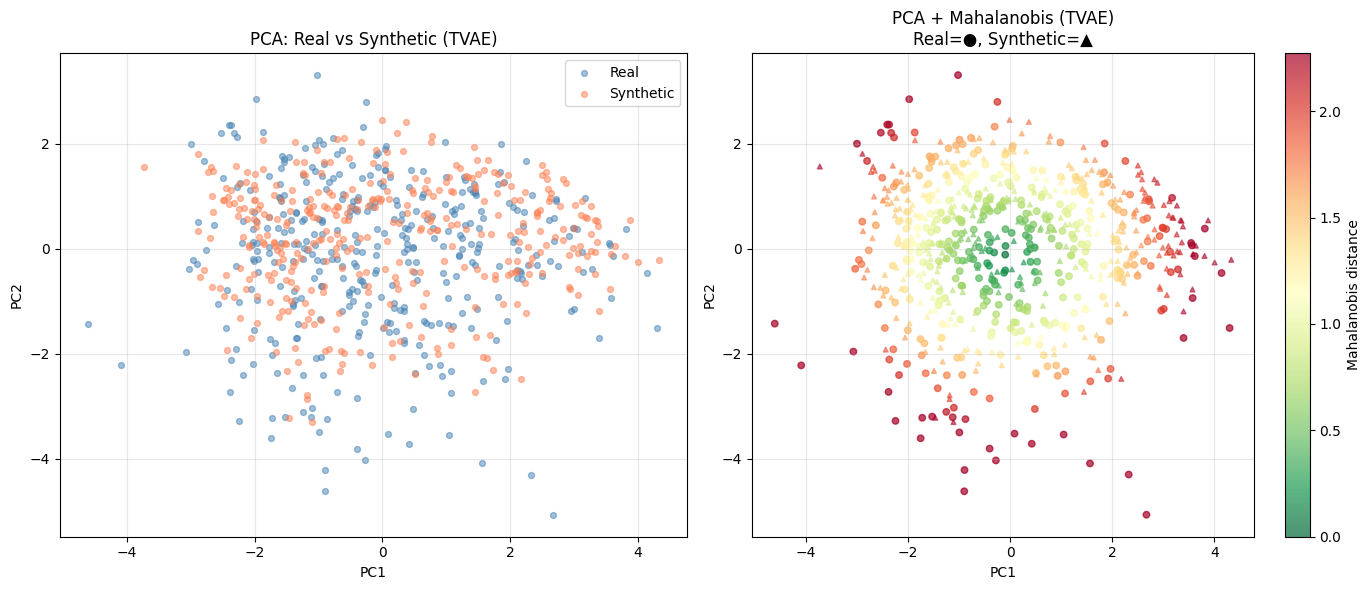

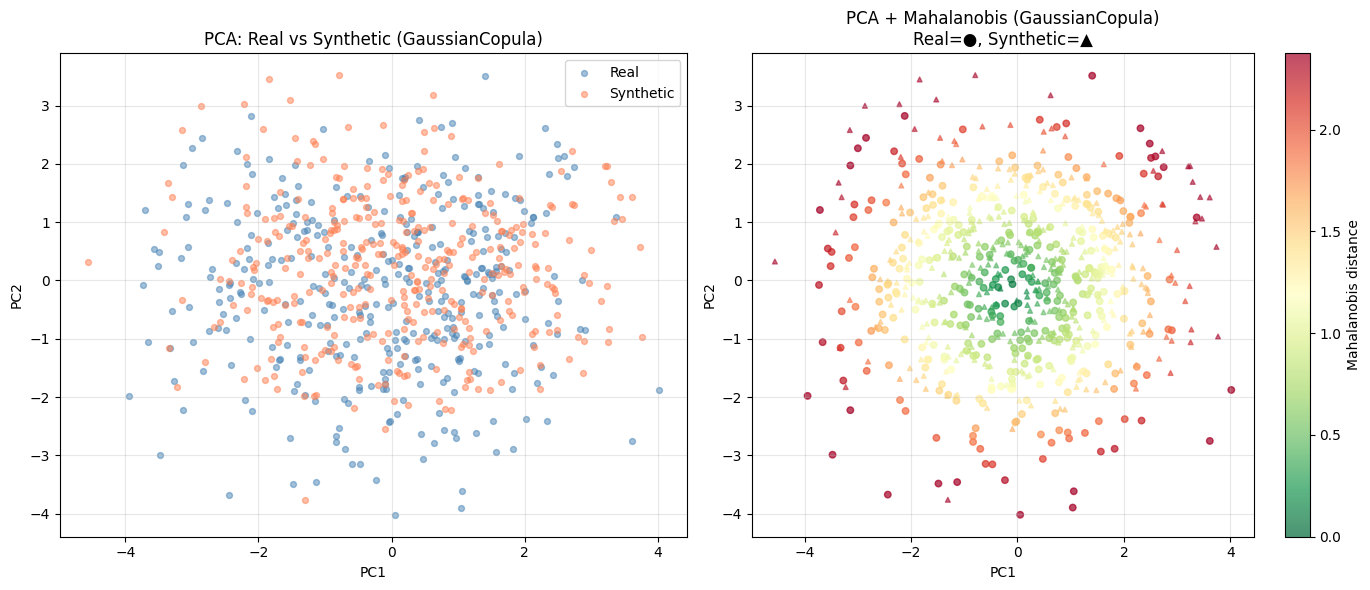

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTGAN,1.274670,1.178543,-0.096127
3,GaussianCopula,1.273048,1.204426,-0.068623
2,TVAE,1.265524,1.291743,0.026220
1,CopulaGAN,1.263063,1.745332,0.482268


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = ad_data.copy()
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "Group"]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)

In [ ]:
# print results on excel sheets 

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_AD.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            matched_df.to_excel(writer, sheet_name=model_name[:31], index=False)

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
real_df = ad_data.copy()
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "Group"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_AD.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_AD.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [ ]:
# MIA with ML regression model 

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "Group"
feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != target_col]

real_df = ad_data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=float)
y_train = real_df[target_col].to_numpy(dtype=int)

X_test = synth_df[feature_cols].to_numpy(dtype=float)
y_test = synth_df[target_col].to_numpy(dtype=int)

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
print(metrics)

{'AUC': 0.7368197859540426, 'Advantage': np.float64(0.34584450402144773), 'TPR_at_FPR_001': np.float64(0.00804289544235925)}


In [ ]:
# MIA with Mahalanobis 

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in ad_data.select_dtypes(include=[np.number]).columns if c != "Group"]
X_train = ad_data[feature_cols].to_numpy(dtype=float)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CopulaGAN,0.992992,0.938338,0.871314,3.022617,12.555755
1,CTGAN,0.987156,0.906166,0.764075,3.022617,11.884804
2,TVAE,0.892402,0.664879,0.112601,3.022617,6.358159
3,GaussianCopula,0.693572,0.364611,0.002681,3.022617,4.027979
